# Do these features separate mitotic figures from the false positives the search actually returns?

**14 ROIs, 2 per tumour type over all 7 domains** (`images/extra_valid`, that folder's
`MANIFEST.md`), and six corrections to the 7-ROI version of this notebook. Every separability
number in this repo before that version compared mitotic figures against **nuclei sampled
uniformly at random**; `morphometric_diagnostic_audit.ipynb` §10 named the gap that leaves:

> *the population you are actually trying to reject is windows that already scored high under
> template matching. Until the negative class is the matcher's own top-K, no separability number
> here is a prediction about your false positives.*

This runs the committed search — `hematoxylin_od` channel, `cv2.TM_CCOEFF`, largest-CC template
tightening, distance NMS — once per ROI, measures a feature vector on **every** surviving
candidate, labels each against ground truth, and asks whether the features separate the classes.

Two labellings: **2-class** (`mitotic` vs `non-mitotic`, the real question) and **3-class**
(`mitotic` / `FP_human`, a MIDOG category-2 look-alike a pathologist marked / `FP`, everything
else).

**No PCA anywhere.** At 0.067–1.15 % prevalence a principal axis cannot carry the class. Clustering
is run at k = 2 and k = 3 only, matched to the number of classes we already know, and scored
*against the true labels* — and now also against the baseline the 7-ROI version never ran.

---

## What changed from `tp_fp_separability.ipynb`

Audited in `Research Logs/2026-09-08-tp-fp-separability-audit.md`; each fix is marked **[Fn]**
where it appears below.

| | defect in the 7-ROI version | fix |
|---|---|---|
| **F1** | §3 set aside 1,211 candidates as "false positives sitting on mitotic figures". `dataset.image_annotations` applies no category filter, so **52 % of them sat on a category-2 look-alike** — a structure a pathologist *rejected*. The look-alike duplicates were removed from the negative class. | Distances are computed against category 1 and category 2 separately. Only the true mitosis-duplicates are set aside; look-alike duplicates stay in the negatives, where they belong. |
| **F2** | §9 re-ranked by `od51` / the supervised score but counted hits with the bucket labels `greedy_match` produced walking the list in **TM-score order**. Greedy matching is order-dependent by construction, so every re-ranker was scored with the wrong assignment. | The match is re-run in each ranker's own order (`cum_hits`). |
| **F3** | `od_falloff` was named the strongest feature and then never put through the reading-depth test. | Every candidate axis goes through the same depth table. |
| **F4** | The supervised gain was quoted against `od51` — an axis `DECISIONS.md` **D5** removed from the arbiter. | Quoted against `z`, the shipped ranker. |
| **F5** | The k = 2 clustering result was never compared with a one-line percentile threshold at the same volume. | The matched-volume threshold is in the table (**F5b**: the correlated pairs left inside the feature set, which distort that clustering's metric, are named rather than summarised as one scalar). |
| **F6** | §1 claimed "nothing below is limited by coverage" without measuring `coverage_fraction`. | Measured and printed. |

Two further changes forced by the ROI count. **Leave-one-domain-out now holds out both ROIs of a
domain** — with 2 ROIs per domain, holding out one file would be exactly the sibling-ROI leak the
7-ROI version criticised in `results/fp_filter_domain.csv`; the fold construction asserts the
disjointness. And **reading depth is measured on the full candidate pool**, including the
duplicates §3 sets aside, because a reader at deployment sees all of them.

**Operating rule for §9**, as briefed: **95 % recall per ROI on average, with a 90 % floor on
every individual ROI.** Both quantities are reported for every ranker; neither is optimised here.


In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.stats import mannwhitneyu
from sklearn.neighbors import KDTree

from midog_utils import dataset as ds
from midog_utils import evaluate as ev

warnings.filterwarnings('ignore')
pd.set_option('display.width', 250)
pd.set_option('display.max_columns', 80)

Z_OP = 1.0                       # the committed operating point: score >= map_median + 1.0*mad
CACHE = '.cache_tail/tp_fp_candidate_features_14roi.csv'      # tp_fp_feature_extract.output_paths()
SUMMARY = 'results/tp_fp_extract_summary_14roi.csv'

cand = pd.read_csv(CACHE)
summ = pd.read_csv(SUMMARY)
TPB, LOOKB, UNANNB = ev.HUMAN_CORRECT_LABEL, ev.HUMAN_REJECTED_LABEL, ev.NON_HUMAN_FINDINGS
IMAGES_DIR = 'images/extra_valid'


def panel_grid(n, w=4.9, h=3.7, ncol=4):
    """A 4-wide grid of exactly n live panels -- 14 ROIs no longer fit the old 2x4."""
    nrow = int(np.ceil(n / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(ncol * w, nrow * h))
    axes = np.atleast_1d(axes).ravel()
    for ax in axes[n:]:
        ax.axis('off')
    return fig, axes


assert cand.file_name.nunique() == summ.file_name.nunique() == len(summ) == 14, (
    'this notebook is the 14-ROI run; point CACHE/SUMMARY at the extra_valid extraction. '
    'Nothing downstream asserts an ROI count on its own -- see the audit log.')

print(f'{len(cand):,} candidates, {cand.file_name.nunique()} ROIs, '
      f'{cand.tumor_type.nunique()} domains, extracted at the deep floor z = -1.5')
print(cand.groupby('tumor_type').file_name.nunique().rename('ROIs').to_string())
print()
print(cand.bucket.value_counts().to_string())


397,148 candidates, 14 ROIs, 7 domains, extracted at the deep floor z = -1.5
tumor_type
canine cutaneous mast cell tumor    2
canine lung cancer                  2
canine lymphosarcoma                2
canine soft tissue sarcoma          2
human breast cancer                 2
human melanoma                      2
human neuroendocrine tumor          2

bucket
non_human_findings      394862
human_correct_label       1311
human_rejected_label       975


## 1. Provenance — is this the pipeline the repo committed?

`tp_fp_feature_extract.py` is `f1_seed_sweep.run_arm`'s `largest_cc` arm at `seed_index = 0`,
including its `np.random.default_rng([0, image_id])` seed stream, run over `images/extra_valid`.
That seed stream is keyed on `image_id` alone, so adding seven ROIs to the loop cannot change what
any of the original seven draws — and the seven they share with `results/f1_seed_sweep.csv` are
gated against it below rather than re-asserted.

**[F6] `coverage_fraction` is printed here**, before any recall number is read. The 7-ROI version
printed `full_list_recall = 1.0` and concluded *"nothing below is limited by coverage"*.
`evaluate.py`'s module docstring says the opposite: a detection list long enough to tile the ROI
answers "was this annotation found?" by geometry. The number belongs on the page.


In [2]:
cols = ['file_name', 'tumor_type', 'template_size', 'seed_ann_id', 'match_radius_px',
        'n_candidates', 'n_gt_mitotic', 'n_tp', 'n_lookalike', 'full_list_recall',
        'shape_fail_rate', 't_search_s']
print(summ[cols].to_string(index=False))

f1 = pd.read_csv('results/f1_seed_sweep.csv')
ref = (f1[(f1.arm_name == 'largest_cc') & (f1.seed_index == 0)]
       .drop_duplicates('file_name').set_index('file_name')[['n_pool', 'tightened_size', 'n_dup_fp']])
chk = summ[summ.file_name.isin(ref.index)].set_index('file_name')[['n_candidates', 'template_size']].join(ref)
gate = bool((chk.n_candidates == chk.n_pool).all() and (chk.template_size == chk.tightened_size).all())
print(f'\nGATE  the {len(chk)} ROIs shared with results/f1_seed_sweep.csv reproduce its candidate '
      f'counts and template sizes exactly: {gate}')
assert gate, 'extraction diverged from the committed 7-ROI run'
print(f'full_list_recall == 1.0 on all {len(summ)} ROIs: {bool((summ.full_list_recall == 1.0).all())}')
print(f'gate-free shape segmentation succeeded on '
      f'{100 * (1 - summ.shape_fail_rate.max()):.3f}% of candidates in the worst ROI')
# Shape features are NaN wherever Otsu found no component at all. `rank(pct=True)` propagates
# that, and StandardScaler / KMeans / roc_auc_score all raise on it -- so the pool has to be
# NaN-free before section 5, and the count has to be visible rather than assumed to be zero.
n_bad = int((~cand.shape_ok).sum())
if n_bad:
    print(f'\nWARNING dropping {n_bad} candidates ({n_bad / len(cand):.4%}) with no Otsu '
          'component -- their shape features are NaN and cannot be ranked')
    cand = cand[cand.shape_ok].reset_index(drop=True)
else:
    print('no candidate has NaN shape features; nothing dropped')

# [F6] the check evaluate.py says to read before any un-budgeted recall number
sm = summ.set_index('file_name')
cov = []
for fn, s in cand[cand.z >= Z_OP].groupby('file_name', sort=False):
    r = sm.loc[fn]
    cov.append({'file_name': fn, 'n_cand_at_z1': len(s),
                'coverage_frac': round(ev.coverage_fraction(
                    s[['cx', 'cy']].to_numpy(), (int(r.roi_h), int(r.roi_w)),
                    float(r.match_radius_px), stride=16), 3)})
cov = pd.DataFrame(cov).sort_values('coverage_frac').reset_index(drop=True)
print(f'\n[F6] coverage_fraction of the z >= {Z_OP} candidate list, per ROI:')
print(cov.to_string(index=False))
print(f'\n     {cov.coverage_frac.min():.1%} to {cov.coverage_frac.max():.1%} of each ROI lies within '
      'the match radius of some candidate.\n'
      '     full_list_recall = 1.0 at this density is therefore substantially GEOMETRIC, and is not\n'
      '     evidence about the detector. What it does establish -- the only thing sections 5 onward\n'
      '     need -- is that the positive class is complete: every mitosis has a candidate on it, so\n'
      '     no separability number below is limited by a missing positive.')


file_name                       tumor_type  template_size  seed_ann_id  match_radius_px  n_candidates  n_gt_mitotic  n_tp  n_lookalike  full_list_recall  shape_fail_rate  t_search_s
 300.tiff canine cutaneous mast cell tumor             45        14581            29.61         23413           180   180           85               1.0              0.0        17.3
 301.tiff canine cutaneous mast cell tumor             41        14969            29.61         25447           217   217          109               1.0              0.0        18.8
 201.tiff               canine lung cancer             51         4457            30.22         22631            17    17           49               1.0              0.0       100.1
 233.tiff               canine lung cancer             25         5761            30.22         33221            17    17           23               1.0              0.0        18.3
 245.tiff             canine lymphosarcoma             47         6274            30.22   


[F6] coverage_fraction of the z >= 1.0 candidate list, per ROI:
file_name  n_cand_at_z1  coverage_frac
 403.tiff         17566          0.743
 013.tiff         15559          0.813
 460.tiff         13208          0.824
 529.tiff         14820          0.833
 201.tiff         16529          0.896
 300.tiff         18451          0.938
 548.tiff         20810          0.939
 094.tiff         26147          0.942
 233.tiff         25286          0.962
 459.tiff         20892          0.965
 301.tiff         22227          0.974
 402.tiff         27280          0.982
 246.tiff         26677          0.992
 245.tiff         36284          0.998

     74.3% to 99.8% of each ROI lies within the match radius of some candidate.
     full_list_recall = 1.0 at this density is therefore substantially GEOMETRIC, and is not
     evidence about the detector. What it does establish -- the only thing sections 5 onward
     need -- is that the positive class is complete: every mitosis has a candidate 

## 2. The candidate pool at the operating point

The committed operating point is `z = 1.0` (`score >= map_median + 1.0 * mad_scale`).
`f1_seed_sweep` verifies that thresholding the deep pool reproduces a fresh extraction at that z
exactly, so subsetting is not an approximation.

In [3]:
op = cand[cand.z >= Z_OP].copy().reset_index(drop=True)

rows = []
for fn, s in op.groupby('file_name', sort=False):
    vc = s.bucket.value_counts()
    n_tp = int(vc.get(TPB, 0))
    rows.append({'file': fn, 'domain': s.tumor_type.iloc[0][:28], 'n_cand': len(s), 'mitotic': n_tp,
                 'FP_human': int(vc.get(LOOKB, 0)), 'FP': int(vc.get(UNANNB, 0)),
                 'prevalence': f'{n_tp / len(s):.3%}'})
print(f'operating point z >= {Z_OP}\n')
print(pd.DataFrame(rows).sort_values('domain').to_string(index=False))
pv = op.groupby('file_name').apply(lambda s: (s.bucket == TPB).mean())
print(f'\npooled: {len(op):,} candidates, {int((op.bucket == TPB).sum())} mitotic, '
      f'base rate {(op.bucket == TPB).mean():.3%}')
print(f'per-ROI prevalence spans {pv.min():.3%} to {pv.max():.3%} -- a '
      f'{pv.max() / pv.min():.0f}x spread, so every pooled number below is reported '
      'beside its per-ROI breakdown')


operating point z >= 1.0



    file                       domain  n_cand  mitotic  FP_human    FP prevalence
300.tiff canine cutaneous mast cell t   18451      180        85 18186     0.976%
301.tiff canine cutaneous mast cell t   22227      217       109 21901     0.976%
201.tiff           canine lung cancer   16529       17        49 16463     0.103%
233.tiff           canine lung cancer   25286       17        22 25247     0.067%
245.tiff         canine lymphosarcoma   36284       89        70 36125     0.245%
246.tiff         canine lymphosarcoma   26677      115       123 26439     0.431%
459.tiff   canine soft tissue sarcoma   20892      130        90 20672     0.622%
460.tiff   canine soft tissue sarcoma   13208       35        40 13133     0.265%
013.tiff          human breast cancer   15559       17        15 15527     0.109%
094.tiff          human breast cancer   26147       81       102 25964     0.310%
529.tiff               human melanoma   14820       19        24 14777     0.128%
548.tiff       

`201.tiff` carries **17 mitotic figures in ~16,500 candidates**, and it is not alone: the
`n >= 15` inclusion bar of `images/extra_valid` admits several ROIs in the teens. Rows from those
appear everywhere below for completeness and should not carry weight — the audit's null
calibration showed what a separability estimate from a handful of positives is worth.

## 3. [F1] One correction before any feature is compared — and it is not the one the 7-ROI version made

`evaluate.greedy_match` gives each ground-truth annotation to **exactly one** detection. NMS runs
at a 5.0 µm radius while the match radius is 7.5 µm — so a second candidate can land inside an
annotation's match circle, on the same object, and still be labelled a false positive.

The 7-ROI version called all of these *"duplicate detections of true positives"* and set them
aside, reasoning that *"a reader who clicked one would not be wrong"*. It built them with

```python
gt = ds.image_annotations(anns, fn)      # <- pools category 1 AND category 2
d, _ = KDTree(gt[['cx','cy']].to_numpy()).query(...)
```

and `dataset.image_annotations` applies **no category filter**. So the distance was to the nearest
annotation of *either* kind, and **52 % of the set sat on a category-2 look-alike** — a structure
a pathologist examined and rejected. A reader clicking one of those *is* wrong, and removing them
from the negative class deleted the hard mimickers that §10 identifies as the unsolved problem.

Below, the two populations are separated. Only candidates within the match radius of a **mitotic**
annotation are set aside. Look-alike duplicates stay in the negatives.

The same definition is used by `f1_seed_sweep.py`'s `n_dup_fp`, which is why the 7-ROI version's
subset assertion passed: the notebook was consistent with the repo, and both were consistent with
a name that did not describe what was counted. `n_dup_fp` is therefore an **upper bound** on the
set aside here, and is still checked as one.


In [4]:
_, anns = ds.load_annotations()
seed_of = summ.set_index('file_name').seed_ann_id

op['dist_mit'] = np.nan       # to the nearest category-1 annotation
op['dist_look'] = np.inf      # to the nearest category-2 annotation
for fn, s in op.groupby('file_name'):
    gt = ds.image_annotations(anns, fn)
    gt = gt[gt.ann_id != int(seed_of[fn])]
    xy = s[['cx', 'cy']].to_numpy()
    mit = gt[gt.category_id == ds.MITOTIC]
    op.loc[s.index, 'dist_mit'] = KDTree(mit[['cx', 'cy']].to_numpy()).query(xy, k=1)[0][:, 0]
    look = gt[gt.category_id == ds.LOOKALIKE]
    if len(look):
        op.loc[s.index, 'dist_look'] = KDTree(look[['cx', 'cy']].to_numpy()).query(xy, k=1)[0][:, 0]

op['match_radius'] = op.file_name.map(summ.set_index('file_name').match_radius_px)
op['on_mitosis'] = (op.bucket == UNANNB) & (op.dist_mit <= op.match_radius)          # set aside
op['on_lookalike'] = (op.bucket == UNANNB) & (~op.on_mitosis) & (op.dist_look <= op.match_radius)
op['on_annotation'] = op.on_mitosis | op.on_lookalike                                # the old rule

f1 = pd.read_csv('results/f1_seed_sweep.csv')
ref = (f1[(f1.arm_name == 'largest_cc') & (f1.seed_index == 0)]
       .drop_duplicates('file_name').set_index('file_name')[['n_pool', 'tightened_size', 'n_dup_fp']])
t = op.groupby('file_name').agg(mitotic=('bucket', lambda b: int((b == TPB).sum())),
                                on_mitosis=('on_mitosis', 'sum'),
                                on_lookalike=('on_lookalike', 'sum'),
                                old_rule=('on_annotation', 'sum'))
t['per mitotic (set aside)'] = (t.on_mitosis / t.mitotic).round(2)
t['% of old rule that was a look-alike'] = (100 * t.on_lookalike / t.old_rule).round(1)
t = t.join(ref['n_dup_fp'].rename('n_dup_fp (f1_seed_sweep)'))
# `results/f1_seed_sweep.csv` holds only the original 7 ROIs, so half these rows join to NaN.
# `int <= NaN` is False in a bool column -- .dropna() would remove nothing and a naive
# .all() would fail on the 7 ROIs that simply have no committed reference. Check the ROIs
# that HAVE one, and say how many were checked.
checkable = t['n_dup_fp (f1_seed_sweep)'].notna()
t['bounded by n_dup_fp'] = np.where(checkable, t.old_rule <= t['n_dup_fp (f1_seed_sweep)'], np.nan)
print(t.to_string())
assert int(checkable.sum()) > 0, 'no ROI has a committed n_dup_fp -- the gate would be vacuous'
assert bool((t.loc[checkable, 'old_rule'] <= t.loc[checkable, 'n_dup_fp (f1_seed_sweep)']).all()), \
    'the old rule exceeds the committed n_dup_fp -- wiring bug'
print(f'\nGATE  old-rule count bounded by n_dup_fp on the {int(checkable.sum())} ROIs '
      f'results/f1_seed_sweep.csv covers; the other {int((~checkable).sum())} have no committed '
      'reference to check against')

print(f'\npooled: {t.mitotic.sum()} mitotic')
print(f'  {t.on_mitosis.sum()} false positives on a MITOSIS      -> set aside '
      f'({t.on_mitosis.sum() / t.mitotic.sum():.2f} per mitotic figure)')
print(f'  {t.on_lookalike.sum()} false positives on a LOOK-ALIKE -> kept in the negatives '
      f'({100 * t.on_lookalike.sum() / t.old_rule.sum():.1f}% of what the old rule removed)')


           mitotic  on_mitosis  on_lookalike  old_rule  per mitotic (set aside)  % of old rule that was a look-alike  n_dup_fp (f1_seed_sweep)  bounded by n_dup_fp
file_name                                                                                                                                                          
013.tiff        17           8            10        18                     0.47                                 55.6                       NaN                  NaN
094.tiff        81          79           143       222                     0.98                                 64.4                     310.0                  1.0
201.tiff        17           6            10        16                     0.35                                 62.5                      33.0                  1.0
233.tiff        17          19            36        55                     1.12                                 65.5                       NaN                  NaN
245.tiff        

**[F1] Set aside: only the mitosis-duplicates.** They are excluded from the negative class from
here on because a reader who clicks one has not made an error. The look-alike duplicates are
kept — clicking one *is* an error, and they are the population §10 is least able to reject.
§6 shows what the choice is worth quantitatively.


In [5]:
# the two labellings, as asked
op['klass3'] = np.where(op.bucket == TPB, 'mitotic',
                np.where(op.bucket == LOOKB, 'FP_human', 'FP'))
op['klass2'] = np.where(op.bucket == TPB, 'mitotic', 'non-mitotic')

work = op[~op.on_mitosis].copy().reset_index(drop=True)   # [F1] only the mitosis-duplicates go
COL3 = {'mitotic': 'tab:red', 'FP_human': 'tab:orange', 'FP': 'tab:blue'}
COL2 = {'mitotic': 'tab:red', 'non-mitotic': 'tab:blue'}
DOMAIN_OF = work.drop_duplicates('file_name').set_index('file_name').tumor_type

print('3-class (mitosis-duplicates removed):')
print(work.klass3.value_counts().to_string())
print(f'\n2-class base rate: {(work.klass2 == "mitotic").mean():.3%}  '
      f'({int((work.klass2 == "mitotic").sum())} of {len(work):,})')
print(f'set aside as duplicate detections of a mitosis: {int(op.on_mitosis.sum())}')
print(f'kept in the negatives, on a look-alike:         {int(op.on_lookalike.sum())}')


3-class (mitosis-duplicates removed):
klass3
FP          298539
mitotic       1311
FP_human       973

2-class base rate: 0.436%  (1311 of 300,823)
set aside as duplicate detections of a mitosis: 913
kept in the negatives, on a look-alike:         900


## 4. Which features, and why these

Nineteen columns were extracted deliberately, to be pruned here rather than at extraction time.
Several measure the same thing. `morphometric_diagnostic_audit.ipynb` §2 turned exactly that kind
of redundancy into a falsification of the previous analysis — `eccentricity` and `elongation` are
one feature written twice — so the correlation structure is looked at first this time.

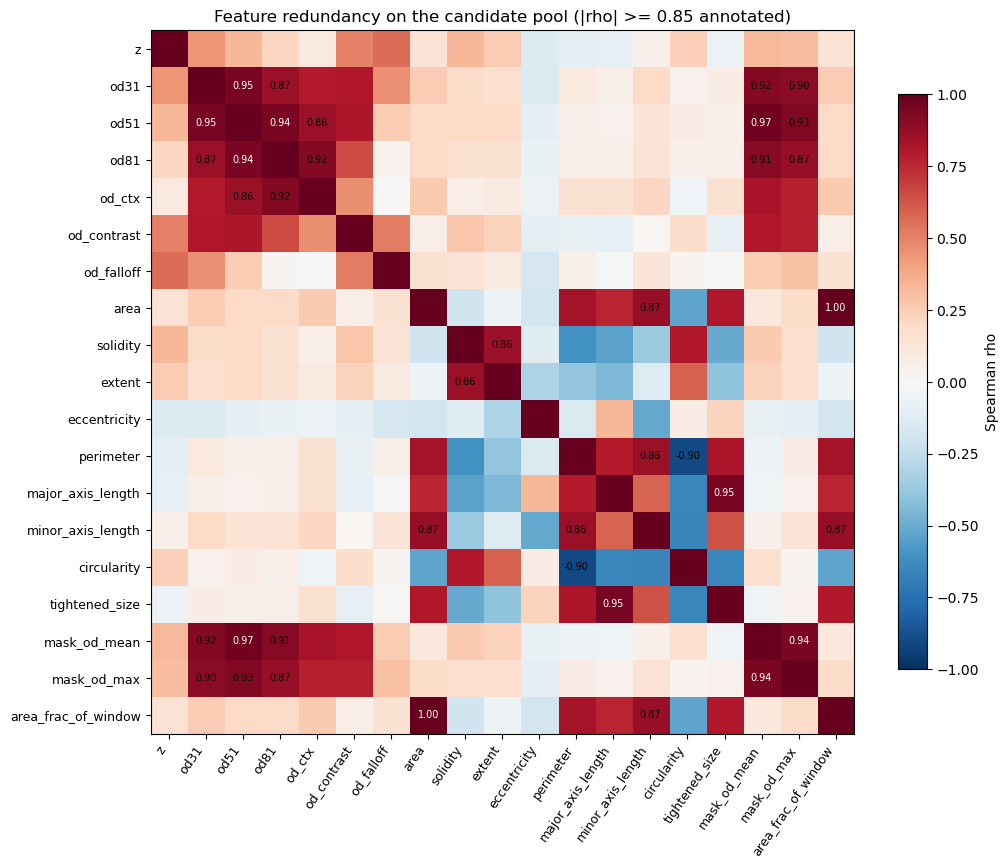

In [6]:
ALL = ['z', 'od31', 'od51', 'od81', 'od_ctx', 'od_contrast', 'od_falloff',
       'area', 'solidity', 'extent', 'eccentricity', 'perimeter', 'major_axis_length',
       'minor_axis_length', 'circularity', 'tightened_size', 'mask_od_mean',
       'mask_od_max', 'area_frac_of_window']
rho = work[ALL].corr(method='spearman')
fig, ax = plt.subplots(figsize=(10.5, 9))
im = ax.imshow(rho, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(ALL))); ax.set_xticklabels(ALL, rotation=55, ha='right', fontsize=9)
ax.set_yticks(range(len(ALL))); ax.set_yticklabels(ALL, fontsize=9)
for i in range(len(ALL)):
    for j in range(len(ALL)):
        if abs(rho.iloc[i, j]) >= 0.85 and i != j:
            ax.text(j, i, f'{rho.iloc[i, j]:.2f}', ha='center', va='center', fontsize=7,
                    color='white' if abs(rho.iloc[i, j]) > 0.93 else 'black')
fig.colorbar(im, ax=ax, shrink=0.75, label='Spearman rho')
ax.set_title('Feature redundancy on the candidate pool (|rho| >= 0.85 annotated)')
fig.tight_layout(); plt.show()

Size is measured five ways and the OD windows are near-duplicates of one another. Left in, any
distance-based clustering would weight the size axis several times over.

**The working set — eight features, one per distinct thing measured:**

| feature | what it measures | why it is here |
|---|---|---|
| `z` | the search score in per-map robust units | the incumbent ranker; it must be in the set or the comparison is unfair to the pipeline. **Never the raw `score`** — `TM_CCOEFF` is unnormalised and scales with template pixel count, and the templates here run 25–51 px |
| `od51` | chromatin density in a 51 px window | the pipeline's own re-ranking key, and the strongest feature in every prior measurement |
| `od_contrast` | `od51 − od_ctx`: darker than its own surround | a **within-image** difference, so it survives OD being uncalibrated between scanners (`chromatin.py`) |
| `od_falloff` | `od31 − od81`: dense core vs diffuse | ditto, and size-free |
| `solidity` | convexity of the segmented object | strongest shape feature in the audit |
| `extent` | fraction of its bounding box filled | second strongest, weakly correlated with `solidity` |
| `tightened_size` | native size of the object | mitoses measured *smaller* in 8 of 9 ROIs |
| `area_frac_of_window` | share of the 51 px window claimed | window-censoring diagnostic and a crude local-density proxy |

Dropped: `eccentricity` (derivable from the axis lengths — the audit's redundancy trap);
`perimeter`, `major_axis_length`, `minor_axis_length`, `circularity`, `area` (size and shape already
carried); `od31`/`od81`/`od_ctx` (kept only inside the two contrasts); `mask_od_mean`/`mask_od_max`
(the component statistic — `chromatin.py` measured it *worse* than the window statistic, 0.895 vs
0.914 on 301.tiff).

In [7]:
FEATURES = ['z', 'od51', 'od_contrast', 'od_falloff',
            'solidity', 'extent', 'tightened_size', 'area_frac_of_window']
sub = rho.loc[FEATURES, FEATURES].abs()
np.fill_diagonal(sub.values, 0.0)
print(f'{len(FEATURES)} features; max |rho| among them: {sub.values.max():.3f}')

# [F5b] the 7-ROI version printed that maximum and moved on. Above 0.85 is the line its own
# heatmap annotates as redundant, so any pair over it is double-weighted in a k-means distance --
# the exact failure mode section 4 warns about for size. Name them rather than print a scalar.
pairs = (sub.stack().sort_values(ascending=False).drop_duplicates())
pairs = pairs[pairs > 0.70].rename('abs_spearman').reset_index()
pairs.columns = ['feature_a', 'feature_b', 'abs_spearman']
pairs['above the 0.85 line'] = pairs.abs_spearman >= 0.85
print('\n[F5] correlated pairs still inside the kept set:')
print(pairs.round(3).to_string(index=False))
print('\n     Shape and size are each carried by two of the eight. Section 8 measures whether that\n'
      '     costs anything -- against a baseline that has no metric to distort.')


8 features; max |rho| among them: 0.856

[F5] correlated pairs still inside the kept set:
     feature_a           feature_b  abs_spearman  above the 0.85 line
        extent            solidity         0.856                 True
          od51         od_contrast         0.810                False
tightened_size area_frac_of_window         0.800                False

     Shape and size are each carried by two of the eight. Section 8 measures whether that
     costs anything -- against a baseline that has no metric to distort.


## 5. Normalisation, settled by measurement

Three of the eight are not comparable across ROIs: `z` (TM_CCOEFF scales with template pixel count,
and templates differ per ROI), `od51` (optical density — `chromatin.py`: *"comparable within one
ROI's ranking and not between ROIs"*), and `tightened_size` (pixels, and microns-per-pixel varies
across these four scanners).

The test, without projecting anything: **try to predict the tumour domain from the features.** If
raw features predict it well, a pooled analysis on raw features is partly a scanner detector.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

rank_all = work.groupby('file_name')[FEATURES].rank(pct=True)
idx = np.random.default_rng(0).choice(len(work), size=20000, replace=False)
y_dom = work.tumor_type.to_numpy()[idx]
for name, X in [('raw (globally standardised)', work[FEATURES].to_numpy(float)),
                ('per-ROI rank transform', rank_all.to_numpy(float))]:
    acc = cross_val_score(make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
                          X[idx], y_dom, cv=3, scoring='accuracy').mean()
    print(f'{name:30s}: domain predictable at {acc:.1%}  (chance = {1 / 7:.1%})')

raw (globally standardised)   : domain predictable at 62.1%  (chance = 14.3%)


per-ROI rank transform        : domain predictable at 20.6%  (chance = 14.3%)


Raw features carry a large amount of domain identity; the per-ROI rank transform removes most of
it. Pooled analyses below therefore use per-ROI ranks. **The cost, stated plainly:** ranking within
each ROI removes all *between*-ROI signal, so nothing pooled can be read as an absolute claim.
`od_contrast` and `od_falloff` are already within-image differences, and per-ROI tables (which need
no normalisation at all) are reported alongside every pooled one.

**And a limit on the test itself.** The rank transform makes every feature's marginal uniform
*within* each ROI by construction, so a linear model on ranked features is close to guaranteed to
lose domain identity. The number above is consistent with the conclusion; it is weaker evidence
for it than it looks. What actually carries the portability claim is that the transform needs no
data from outside the ROI being ranked — it is available on an unseen domain by construction.

## 6. The measurement: do the features separate the classes?

Signed AUC — 0.5 is nothing, above 0.5 means the mitotic class scores higher — plus **average
precision against the base rate**, because at 0.067–1.15 % prevalence an AUC is a poor guide to what a
reader working down the list experiences.


In [9]:
def auc(a, b):
    a = np.asarray(a, float); a = a[~np.isnan(a)]
    b = np.asarray(b, float); b = b[~np.isnan(b)]
    if len(a) < 5 or len(b) < 5:
        return np.nan
    return mannwhitneyu(a, b, alternative='two-sided').statistic / (len(a) * len(b))


def auc_table(df, pos, neg, title, kcol='klass3'):
    rows = []
    for fn, s in df.groupby('file_name', sort=False):
        p, n = s[s[kcol] == pos], s[s[kcol] == neg]
        if len(p) < 5 or len(n) < 5:
            continue
        r = {'file': fn, 'domain': s.tumor_type.iloc[0][:24], 'n_pos': len(p), 'n_neg': len(n)}
        for f in FEATURES:
            r[f] = round(auc(p[f], n[f]), 3)
        rows.append(r)
    t = pd.DataFrame(rows)
    print(f'=== {title} ===\n')
    print(t.to_string(index=False))
    print('\nmedian |AUC - 0.5| across ROIs:')
    print((t[FEATURES] - 0.5).abs().median().round(3).sort_values(ascending=False).to_string())
    return t


auc2 = auc_table(work, 'mitotic', 'non-mitotic', '2-CLASS: mitotic vs non-mitotic', 'klass2')

=== 2-CLASS: mitotic vs non-mitotic ===

    file                   domain  n_pos  n_neg     z  od51  od_contrast  od_falloff  solidity  extent  tightened_size  area_frac_of_window
300.tiff canine cutaneous mast ce    180  18228 0.930 0.955        0.956       0.976     0.777   0.648           0.210                0.220
301.tiff canine cutaneous mast ce    217  21895 0.930 0.932        0.948       0.971     0.747   0.690           0.094                0.105
201.tiff       canine lung cancer     17  16506 0.994 0.995        0.996       0.976     0.889   0.743           0.087                0.124
233.tiff       canine lung cancer     17  25250 0.993 0.981        0.991       0.995     0.897   0.773           0.110                0.214
245.tiff     canine lymphosarcoma     89  36010 0.876 0.869        0.905       0.854     0.603   0.530           0.310                0.263
246.tiff     canine lymphosarcoma    115  26446 0.983 0.972        0.978       0.991     0.931   0.856           0.120 

In [10]:
aucFP = auc_table(work, 'mitotic', 'FP', '3-CLASS a: mitotic vs FP (unannotated -- 90%+ of the mass)')

=== 3-CLASS a: mitotic vs FP (unannotated -- 90%+ of the mass) ===

    file                   domain  n_pos  n_neg     z  od51  od_contrast  od_falloff  solidity  extent  tightened_size  area_frac_of_window
300.tiff canine cutaneous mast ce    180  18143 0.931 0.956        0.957       0.977     0.778   0.648           0.209                0.219
301.tiff canine cutaneous mast ce    217  21786 0.931 0.933        0.949       0.972     0.748   0.691           0.092                0.103
201.tiff       canine lung cancer     17  16457 0.994 0.996        0.997       0.977     0.890   0.744           0.086                0.123
233.tiff       canine lung cancer     17  25228 0.993 0.982        0.991       0.996     0.897   0.774           0.109                0.214
245.tiff     canine lymphosarcoma     89  35940 0.877 0.869        0.906       0.855     0.603   0.530           0.310                0.263
246.tiff     canine lymphosarcoma    115  26323 0.984 0.973        0.979       0.993     0.9

In [11]:
aucH = auc_table(work, 'mitotic', 'FP_human',
                 '3-CLASS b: mitotic vs FP_human (pathologist-marked look-alikes)')

=== 3-CLASS b: mitotic vs FP_human (pathologist-marked look-alikes) ===

    file                   domain  n_pos  n_neg     z  od51  od_contrast  od_falloff  solidity  extent  tightened_size  area_frac_of_window
300.tiff canine cutaneous mast ce    180     85 0.734 0.735        0.721       0.755     0.572   0.572           0.405                0.423
301.tiff canine cutaneous mast ce    217    109 0.678 0.683        0.686       0.699     0.544   0.549           0.422                0.425
201.tiff       canine lung cancer     17     49 0.797 0.773        0.767       0.643     0.467   0.555           0.471                0.475
233.tiff       canine lung cancer     17     22 0.783 0.874        0.885       0.754     0.636   0.586           0.436                0.570
245.tiff     canine lymphosarcoma     89     70 0.600 0.594        0.584       0.524     0.535   0.466           0.414                0.380
246.tiff     canine lymphosarcoma    115    123 0.733 0.783        0.780       0.760   

In [12]:
# [F1] the control, split by what the "duplicate" actually sits on.
# Left half: candidates on a MITOSIS -- these are the ones the 7-ROI version described.
# Right half: candidates on a LOOK-ALIKE -- 52% of that version's set, and NOT duplicates
# of a true positive at all. They stay in the negatives; this shows what they look like.
ctrl = op[op.on_mitosis | (op.bucket == TPB)].copy()
ctrl['klass2'] = np.where(ctrl.bucket == TPB, 'mitotic', 'non-mitotic')
aucC = auc_table(ctrl, 'mitotic', 'non-mitotic',
                 'CONTROL a: mitotic vs the duplicate detections of MITOSES (set aside)', 'klass2')

ctrl_l = op[op.on_lookalike | (op.bucket == TPB)].copy()
ctrl_l['klass2'] = np.where(ctrl_l.bucket == TPB, 'mitotic', 'non-mitotic')
aucCL = auc_table(ctrl_l, 'mitotic', 'non-mitotic',
                  'CONTROL b: mitotic vs the candidates on a LOOK-ALIKE (kept in the negatives)',
                  'klass2')


=== CONTROL a: mitotic vs the duplicate detections of MITOSES (set aside) ===

    file                   domain  n_pos  n_neg     z  od51  od_contrast  od_falloff  solidity  extent  tightened_size  area_frac_of_window
300.tiff canine cutaneous mast ce    180     43 0.956 0.782        0.788       0.900     0.703   0.575           0.523                0.585
301.tiff canine cutaneous mast ce    217    115 0.926 0.705        0.720       0.915     0.575   0.533           0.523                0.595
201.tiff       canine lung cancer     17      6 1.000 0.755        0.755       1.000     0.431   0.402           0.824                0.961
233.tiff       canine lung cancer     17     19 0.954 0.777        0.789       1.000     0.331   0.260           0.746                0.830
245.tiff     canine lymphosarcoma     89    185 0.880 0.556        0.582       0.721     0.538   0.486           0.453                0.442
246.tiff     canine lymphosarcoma    115    116 0.944 0.735        0.754       0.

=== CONTROL b: mitotic vs the candidates on a LOOK-ALIKE (kept in the negatives) ===

    file                   domain  n_pos  n_neg     z  od51  od_contrast  od_falloff  solidity  extent  tightened_size  area_frac_of_window
300.tiff canine cutaneous mast ce    180     22 0.974 0.831        0.810       0.974     0.580   0.517           0.469                0.521
301.tiff canine cutaneous mast ce    217     83 0.939 0.783        0.796       0.930     0.643   0.565           0.402                0.475
201.tiff       canine lung cancer     17     10 0.982 0.947        0.947       1.000     0.647   0.547           0.594                0.647
233.tiff       canine lung cancer     17     36 0.975 0.964        0.956       0.997     0.778   0.738           0.364                0.613
245.tiff     canine lymphosarcoma     89    141 0.912 0.690        0.698       0.755     0.570   0.501           0.373                0.373
246.tiff     canine lymphosarcoma    115    150 0.981 0.890        0.895  

**Neither control comes back at 0.5, and the split is the point.** `z` and `od_falloff` read high
against both halves: the mitotic *centre* is markedly darker and more sharply peaked than a
detection 20–30 px away on the same object, whatever that object is. So the set-aside candidates
are ordinary weak candidates, not disguised positives.

**[F1] But the two halves are not the same population, and the 7-ROI version averaged them.** The
`od51` separation is systematically *weaker* against the mitosis-duplicates than against the
look-alike ones — a candidate sitting on the rim of a real mitosis is a harder negative than one
sitting on a mimicker. Pooling them, as the old rule did, and then deleting the pool, removed the
harder half from the negative class along with the softer.

Note what still reads near 0.5 in both tables: `extent` and `solidity`. The shape of the largest
component in the window barely changes when the window slides 20 px, while the chromatin
statistics change a great deal. The features that separate mitoses from false positives are partly
measuring *centredness on a dense object*, which is worth knowing when reading §9.


In [13]:
# [F1] how much does the corrected set-aside actually change the answer?
#   old rule  = drop everything within the match radius of ANY annotation (52% look-alikes)
#   new rule  = drop only what sits on a MITOSIS
#   none      = drop nothing
rows = []
for fn in work.file_name.unique():
    frames = {'new': work[work.file_name == fn],
              'old': op[(op.file_name == fn) & ~op.on_annotation],
              'none': op[op.file_name == fn]}
    r = {'file': fn}
    for f in ['z', 'od51', 'od_falloff', 'solidity']:
        vals = {}
        for k, d in frames.items():
            kl = np.where(d.bucket == TPB, 'mitotic', 'non-mitotic')
            vals[k] = auc(d[f][kl == 'mitotic'], d[f][kl == 'non-mitotic'])
        r[f'{f} new'] = round(vals['new'], 3)
        r[f'{f} old-rule delta'] = round(vals['old'] - vals['new'], 4)
        r[f'{f} keep-all delta'] = round(vals['none'] - vals['new'], 4)
    rows.append(r)
delta = pd.DataFrame(rows)
print('2-class AUC under the corrected set-aside, and what the other two rules would have given\n')
print(delta.to_string(index=False))
dcols = [c for c in delta.columns if 'delta' in c]
print(f'\nlargest absolute change from the set-aside rule: {delta[dcols].abs().max().max():.4f}')
print('\nThe rule is quantitatively almost free either way -- which is exactly why the 7-ROI\n'
      "version's error survived: it changed no number it reported. It changed WHICH candidates\n"
      'were being called false positives, and that is a labelling claim, not a measurement.')


2-class AUC under the corrected set-aside, and what the other two rules would have given

    file  z new  z old-rule delta  z keep-all delta  od51 new  od51 old-rule delta  od51 keep-all delta  od_falloff new  od_falloff old-rule delta  od_falloff keep-all delta  solidity new  solidity old-rule delta  solidity keep-all delta
300.tiff  0.930           -0.0001            0.0001     0.955               0.0001              -0.0004           0.976                     0.0000                    -0.0002         0.777                   0.0002                  -0.0002
301.tiff  0.930           -0.0000           -0.0000     0.932               0.0006              -0.0012           0.971                     0.0002                    -0.0003         0.747                   0.0004                  -0.0009
201.tiff  0.994            0.0000            0.0000     0.995               0.0000              -0.0001           0.976                    -0.0000                     0.0000         0.889         

**[F1] The choice is quantitatively almost free, and that is the point.** The largest AUC change
from any of the three set-aside rules — correct, old, or keep-everything — is printed above and is
a fraction of a percentage point. The 7-ROI version's error survived precisely because of this: it
changed no number that version reported.

What it changed is **which candidates are called false positives**. That is a labelling claim, not
a measurement, and it is not free: the 900 look-alike duplicates the old rule deleted are second
detections of structures a pathologist examined and *rejected*, i.e. the population §11 identifies
as the one no feature in this set can touch. They are back in the negative class here.

The mitosis-duplicates stay out, for the reason the 7-ROI version gave and which does survive: a
reader who clicks one has not made an error.


In [14]:
from sklearn.metrics import average_precision_score

rows = []
for fn, s in work.groupby('file_name', sort=False):
    y = (s.klass2 == 'mitotic').astype(int).to_numpy()
    br = y.mean()
    r = {'file': fn, 'n': len(s), 'base rate': f'{br:.3%}'}
    for f in ['z', 'od51', 'od_contrast', 'solidity', 'extent', 'tightened_size']:
        v = s[f].to_numpy(float)
        a = auc(s[f][y == 1], s[f][y == 0])
        ap = average_precision_score(y, v if a >= 0.5 else -v)
        r[f] = f'{a:.3f} / {ap / br:.0f}x'
    rows.append(r)
print('AUC / average-precision lift over the base rate, per ROI, 2-class\n')
print(pd.DataFrame(rows).to_string(index=False))
print('\n(a feature with AUC 0.8 and AP lift 5x separates statistically and barely helps a reader)')

AUC / average-precision lift over the base rate, per ROI, 2-class

    file     n base rate            z         od51  od_contrast   solidity     extent tightened_size
300.tiff 18408    0.978%  0.930 / 35x  0.955 / 56x  0.956 / 55x 0.777 / 3x 0.648 / 2x     0.210 / 3x
301.tiff 22112    0.981%  0.930 / 41x  0.932 / 46x  0.948 / 51x 0.747 / 2x 0.690 / 2x     0.094 / 8x
201.tiff 16523    0.103% 0.994 / 221x 0.995 / 228x 0.996 / 277x 0.889 / 8x 0.743 / 3x     0.087 / 8x
233.tiff 25267    0.067% 0.993 / 432x 0.981 / 499x 0.991 / 811x 0.897 / 6x 0.773 / 3x     0.110 / 5x
245.tiff 36099    0.247%   0.876 / 9x  0.869 / 16x  0.905 / 17x 0.603 / 1x 0.530 / 1x     0.310 / 2x
246.tiff 26561    0.433% 0.983 / 106x 0.972 / 103x 0.978 / 106x 0.931 / 9x 0.856 / 4x     0.120 / 4x
459.tiff 20862    0.623%  0.922 / 38x  0.928 / 79x  0.937 / 69x 0.708 / 2x 0.657 / 2x     0.307 / 2x
460.tiff 13204    0.265% 0.928 / 139x 0.938 / 177x 0.950 / 183x 0.743 / 2x 0.750 / 3x     0.297 / 2x
013.tiff 15551    0.109%

### The same features, drawn with the classes highlighted

Per-ROI percentile on the x-axis so all 14 ROIs are on one scale, densities normalised **within
class** so the ~200:1 imbalance does not hide the mitotic distribution. A feature that separates
shows two displaced curves; a feature that does not shows one curve drawn twice.


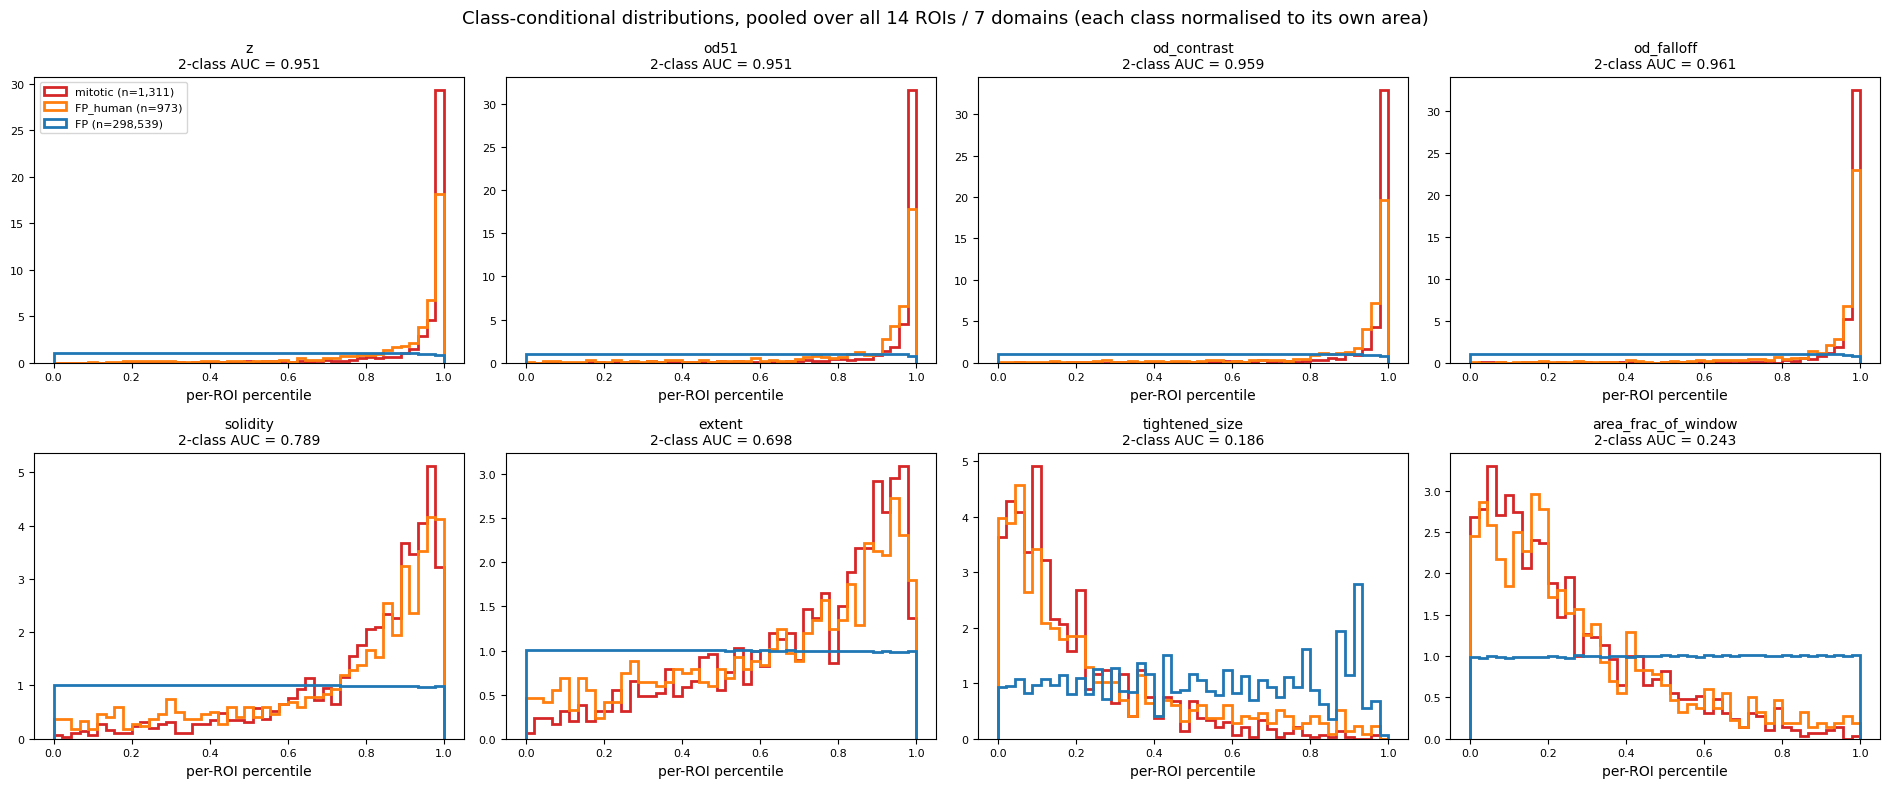

In [15]:
rk = work.groupby('file_name')[FEATURES].rank(pct=True)
fig, axes = plt.subplots(2, 4, figsize=(19, 8))
for ax, f in zip(axes.ravel(), FEATURES):
    bins = np.linspace(0, 1, 46)
    for k, c in COL3.items():
        v = rk[f][(work.klass3 == k).to_numpy()]
        ax.hist(v, bins=bins, density=True, histtype='step', lw=2, color=c,
                label=f'{k} (n={len(v):,})')
    a = auc(rk[f][(work.klass2 == 'mitotic').to_numpy()],
            rk[f][(work.klass2 == 'non-mitotic').to_numpy()])
    ax.set_title(f'{f}\n2-class AUC = {a:.3f}', fontsize=10)
    ax.set_xlabel('per-ROI percentile'); ax.tick_params(labelsize=8)
axes[0, 0].legend(fontsize=8)
fig.suptitle(f'Class-conditional distributions, pooled over all {work.file_name.nunique()} ROIs / '
             f'{work.tumor_type.nunique()} domains (each class normalised to its own area)',
             fontsize=13)
fig.tight_layout(); plt.show()


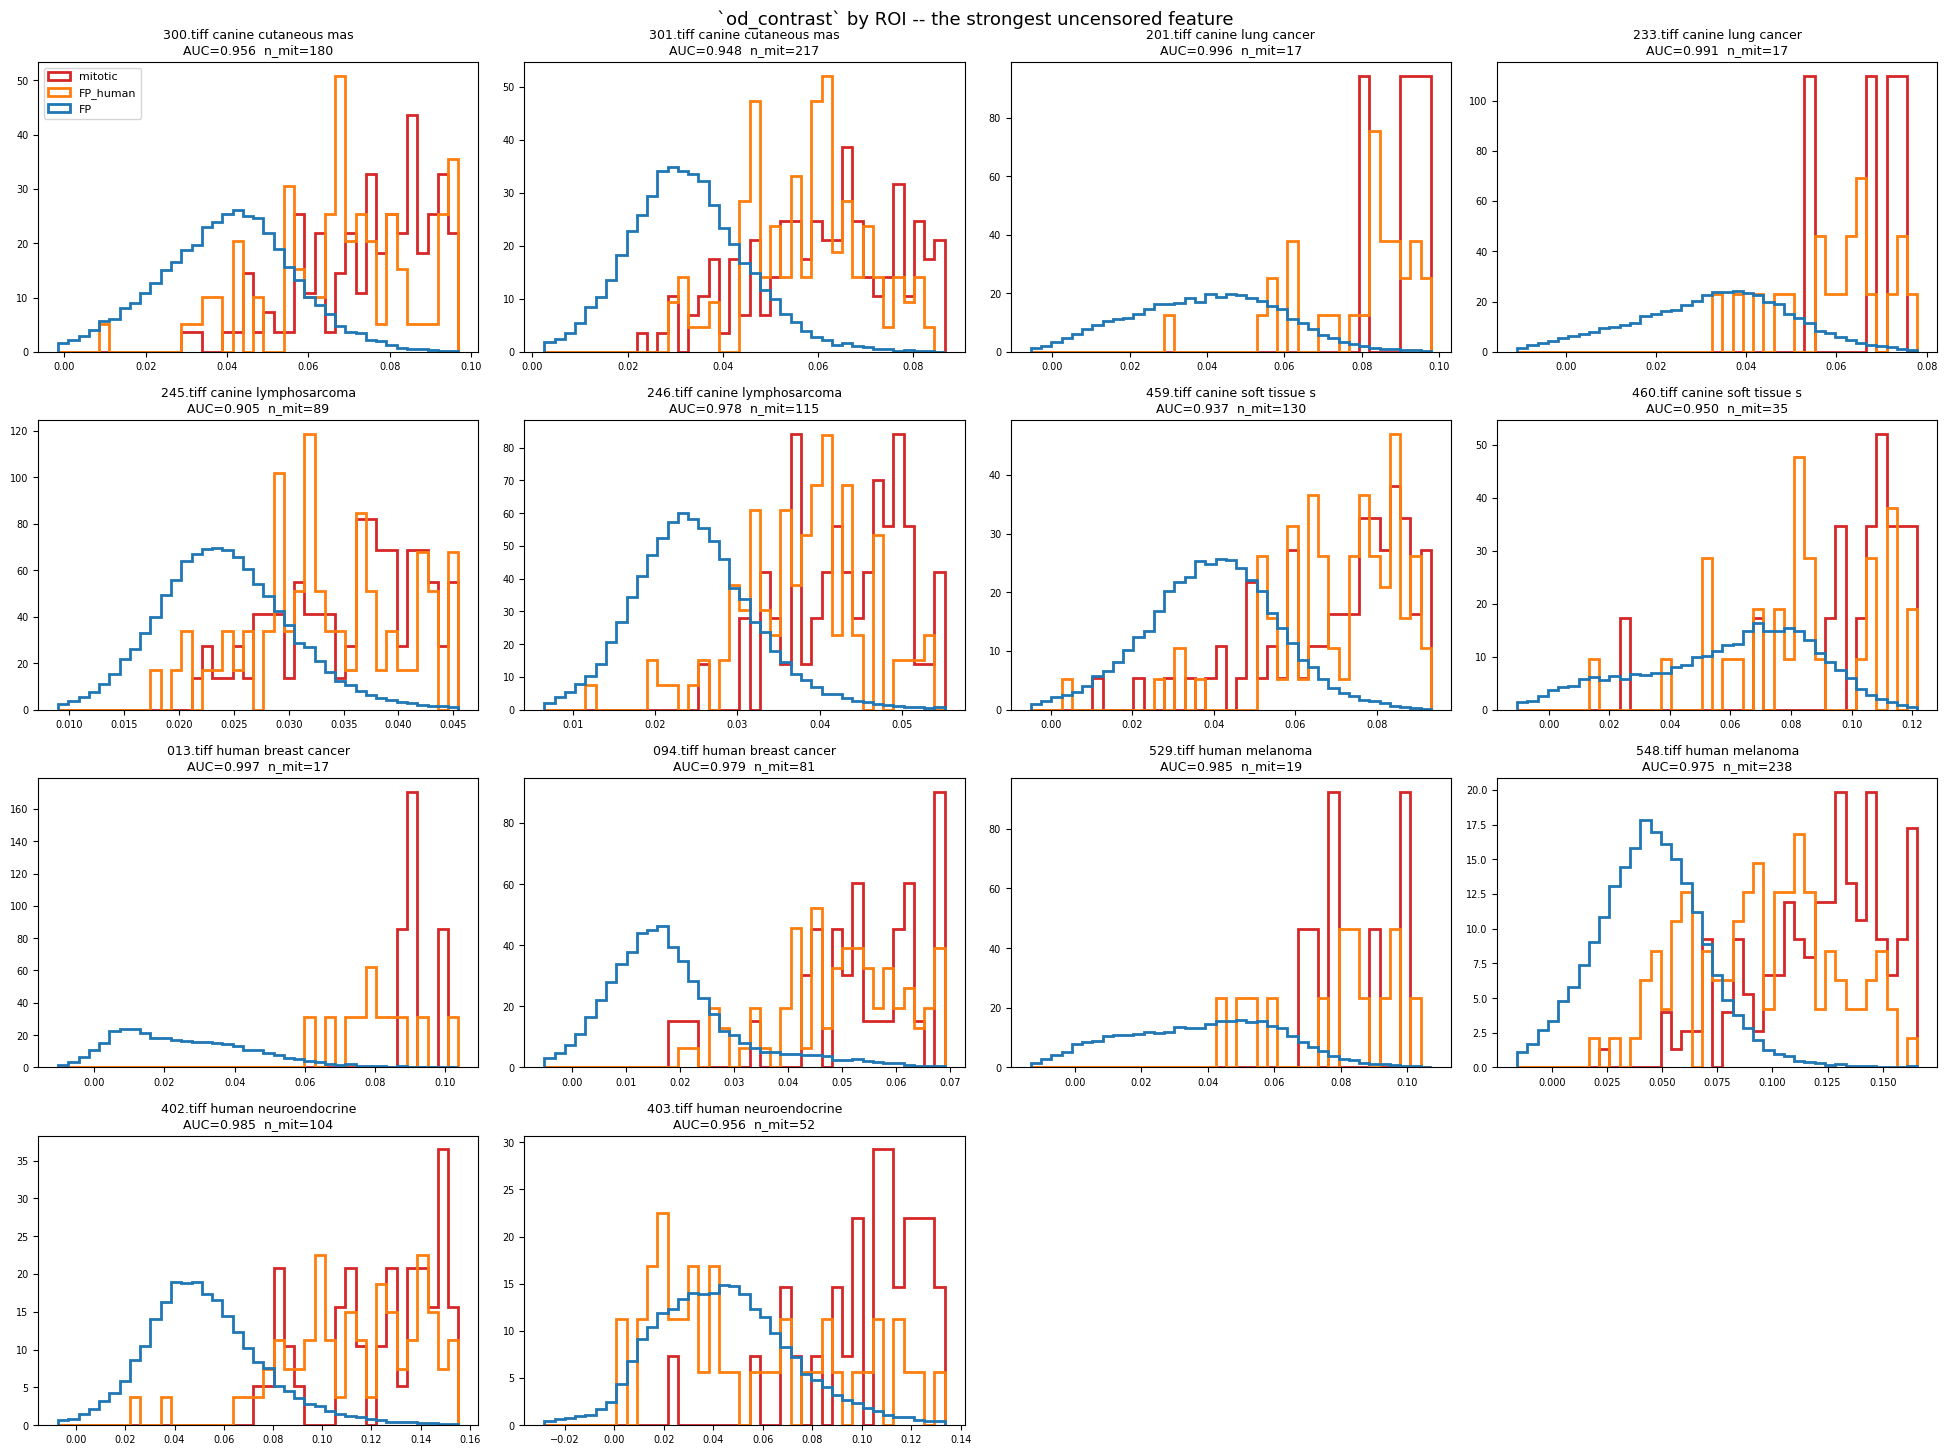

In [16]:
# and per ROI, for the single strongest feature -- "in every domain", as asked
best_f = (auc2[[f for f in FEATURES if f != 'z']] - 0.5).abs().median().idxmax()
fig, axes = panel_grid(work.file_name.nunique())
for ax, (fn, s) in zip(axes, work.groupby('file_name', sort=False)):
    bins = np.linspace(s[best_f].quantile(0.005), s[best_f].quantile(0.995), 40)
    for k, c in COL3.items():
        v = s[best_f][s.klass3 == k]
        if len(v) > 4:
            ax.hist(v, bins=bins, density=True, histtype='step', lw=2, color=c, label=k)
    a = auc(s[best_f][s.klass2 == 'mitotic'], s[best_f][s.klass2 == 'non-mitotic'])
    ax.set_title(f'{fn} {s.tumor_type.iloc[0][:20]}\n'
                 f'AUC={a:.3f}  n_mit={int((s.klass3 == "mitotic").sum())}', fontsize=9)
    ax.tick_params(labelsize=7)
axes[0].legend(fontsize=8)
fig.suptitle(f'`{best_f}` by ROI -- the strongest uncensored feature', fontsize=13)
fig.tight_layout(); plt.show()


## 7. Two features at a time, classes highlighted

No projection: these are the two most discriminative features plotted directly against each other,
on per-ROI percentile axes.

The rendering matters. Drawing ~300,000 negatives and ~1,300 positives as one scatter with the
positives on top manufactures apparent separation out of draw order. **Left:** negatives as a
log-count density, mitotic figures as points. **Right:** the same axes with the negatives
subsampled to equal n — the honest comparison.


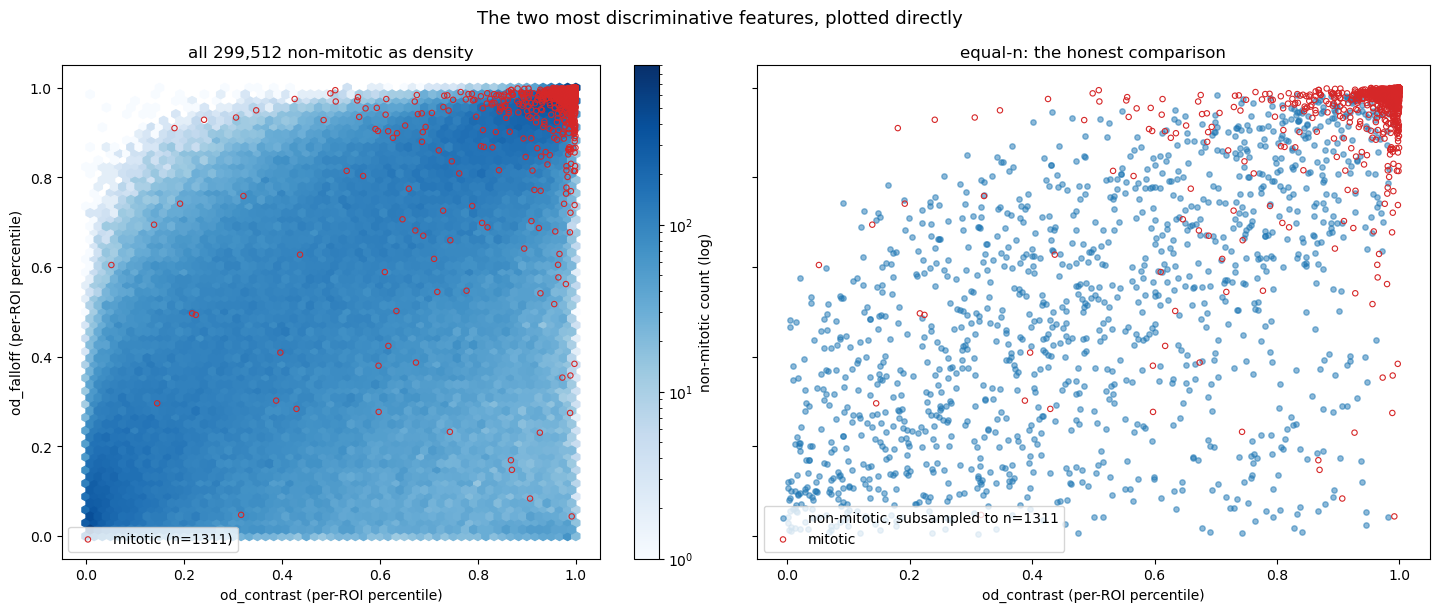

In [17]:
uncens = [f for f in FEATURES if f != 'z']
order = (auc2[uncens] - 0.5).abs().median().sort_values(ascending=False)
fa, fb = order.index[0], order.index[1]
mit = (work.klass2 == 'mitotic').to_numpy()
neg = ~mit
rng = np.random.default_rng(0)
eq = rng.choice(np.flatnonzero(neg), size=int(mit.sum()), replace=False)
xa, xb = rk[fa].to_numpy(), rk[fb].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(14.5, 6.2), sharex=True, sharey=True)
hb = axes[0].hexbin(xa[neg], xb[neg], gridsize=60, cmap='Blues', norm=LogNorm(), mincnt=1)
fig.colorbar(hb, ax=axes[0], label='non-mitotic count (log)')
axes[0].scatter(xa[mit], xb[mit], s=15, facecolor='none', edgecolor='tab:red', lw=0.8,
                label=f'mitotic (n={int(mit.sum())})')
axes[0].legend(loc='lower left'); axes[0].set_title(f'all {int(neg.sum()):,} non-mitotic as density')
axes[1].scatter(xa[eq], xb[eq], s=15, color='tab:blue', alpha=0.5,
                label=f'non-mitotic, subsampled to n={len(eq)}')
axes[1].scatter(xa[mit], xb[mit], s=15, facecolor='none', edgecolor='tab:red', lw=0.8,
                label='mitotic')
axes[1].legend(loc='lower left'); axes[1].set_title('equal-n: the honest comparison')
for ax in axes:
    ax.set_xlabel(f'{fa} (per-ROI percentile)')
axes[0].set_ylabel(f'{fb} (per-ROI percentile)')
fig.suptitle(f'The two most discriminative features, plotted directly', fontsize=13)
fig.tight_layout(); plt.show()

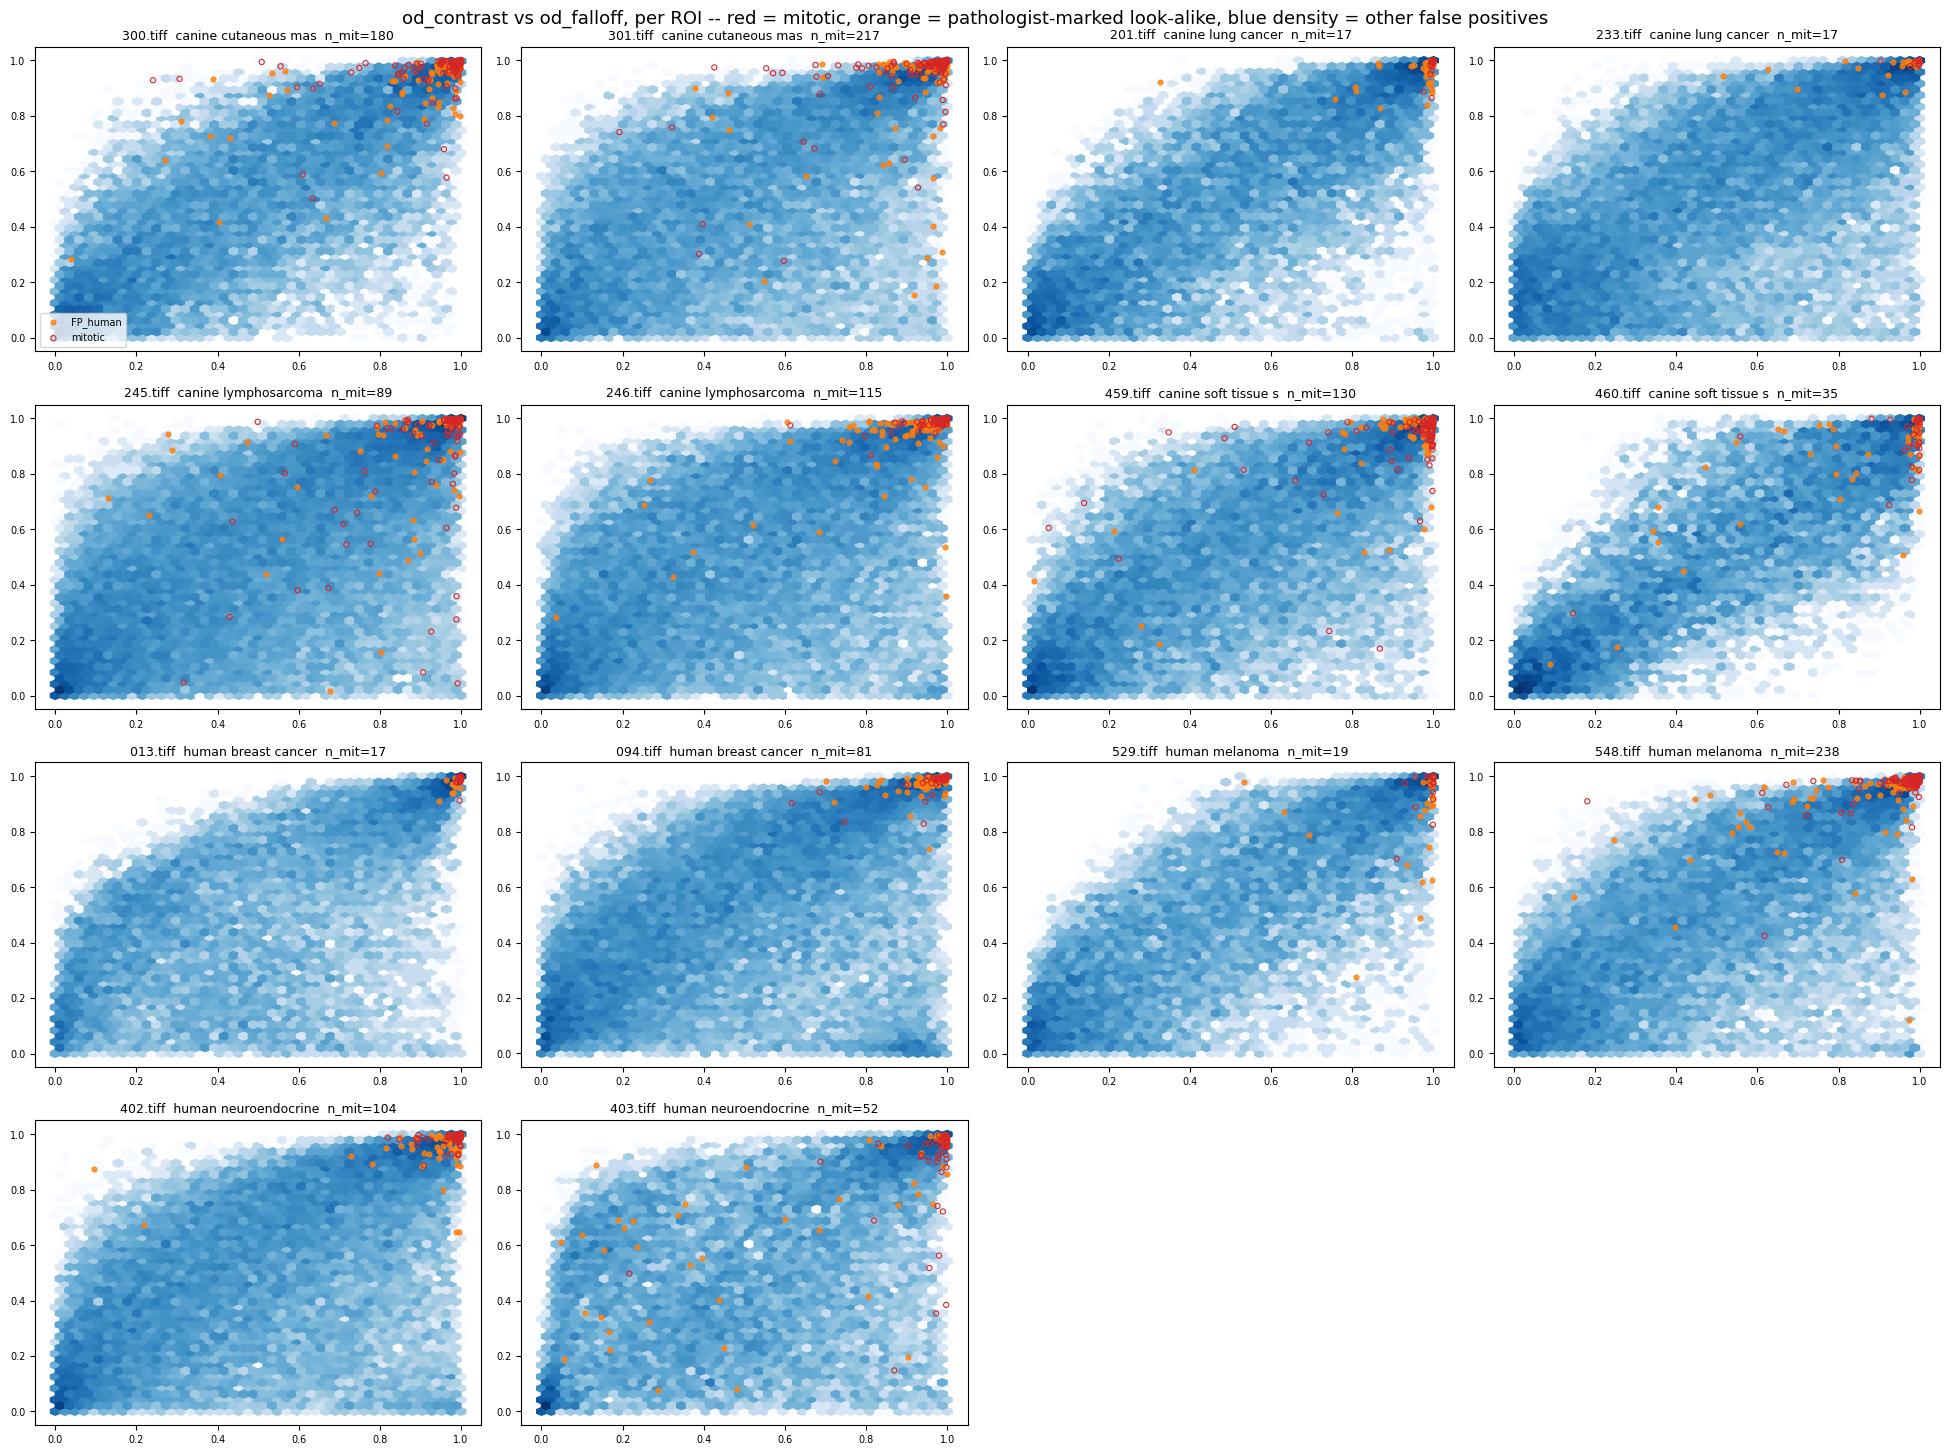

In [18]:
fig, axes = panel_grid(work.file_name.nunique())
for ax, (fn, s) in zip(axes, work.groupby('file_name', sort=False)):
    r_ = s[FEATURES].rank(pct=True)
    m = (s.klass2 == 'mitotic').to_numpy()
    h = (s.klass3 == 'FP_human').to_numpy()
    ax.hexbin(r_[fa][~m & ~h], r_[fb][~m & ~h], gridsize=42, cmap='Blues',
              norm=LogNorm(), mincnt=1)
    ax.scatter(r_[fa][h], r_[fb][h], s=12, color='tab:orange', alpha=0.8, label='FP_human')
    ax.scatter(r_[fa][m], r_[fb][m], s=14, facecolor='none', edgecolor='tab:red', lw=0.8,
               label='mitotic')
    ax.set_title(f'{fn}  {s.tumor_type.iloc[0][:20]}  n_mit={int(m.sum())}', fontsize=9)
    ax.tick_params(labelsize=7)
axes[0].legend(fontsize=7, loc='lower left')
fig.suptitle(f'{fa} vs {fb}, per ROI -- red = mitotic, orange = pathologist-marked look-alike, '
             'blue density = other false positives', fontsize=13)
fig.tight_layout(); plt.show()


## 8. Clustering at k = 2 and k = 3 — against the labels, and against the baseline that matters

The class count is known, so k is fixed to it rather than swept. Reported:

* **purity** of the mitotic-richest cluster and its **enrichment** over the base rate;
* **adjusted Rand index** against the true labels. Expect this near zero and **do not read it as
  "the clustering failed"** — ARI compares two partitions as partitions, and one side here has a
  ~0.5 % class against clusters holding tens of thousands of points;
* **a permutation null** — labels shuffled *within ROI* so each ROI's base rate is preserved, 500
  draws. Enrichment of a best-of-k cluster has a non-zero null, and without the band a 1.5x lift
  reads as a finding;
* **[F5] the matched-volume threshold.** *This is the column the 7-ROI version was missing.* If a
  cluster holds half the pool and almost all the mitoses, the question is not whether it beats
  chance — it is whether it beats keeping that same share by a single feature's per-ROI percentile.
  A permutation null answers *is this structure real*; the product question is *does it beat
  `sort()`*. Both are now on the page.

k-means is used because it is the method most favourable to the hypothesis: if the mitotic figures
occupy a compact corner of this space, a 2-means split finds it. A Gaussian mixture is run beside
it because it can carve an elongated cluster k-means cannot.


In [19]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from sklearn.mixture import GaussianMixture

X = rk.to_numpy(float)
y2 = (work.klass2 == 'mitotic').to_numpy().astype(int)
roi = work.file_name.to_numpy()
BASE = y2.mean()
N_PERM = 500


def enrich_of_best(labels, yv, min_n=50):
    n = np.bincount(labels)
    t = np.bincount(labels, weights=yv)
    rate = np.where(n >= min_n, t / np.maximum(n, 1), 0.0)
    e = rate / yv.mean()
    return float(e.max()), int(np.argmax(e))


def perm_null(labels, yv, roi_v, n_perm=N_PERM, seed=0):
    g = np.random.default_rng(seed)
    groups = [np.flatnonzero(roi_v == r) for r in np.unique(roi_v)]
    out = np.empty(n_perm)
    yp = yv.copy()
    for i in range(n_perm):
        for ix in groups:
            yp[ix] = g.permutation(yv[ix])
        out[i] = enrich_of_best(labels, yp)[0]
    return out


def recall_at_volume(frame, yv, feat, keep_frac):
    """[F5] recall of a per-ROI percentile threshold that retains `keep_frac` of the pool."""
    v = frame.groupby('file_name')[feat].rank(pct=True).to_numpy()
    return float(yv[v >= np.quantile(v, 1 - keep_frac)].sum() / yv.sum())


fits = {}
rows = []
for k in (2, 3):
    for name, mdl in [('k-means', KMeans(n_clusters=k, n_init=10, random_state=0)),
                      ('GMM', GaussianMixture(n_components=k, covariance_type='full',
                                              random_state=0, max_iter=200))]:
        lab = mdl.fit_predict(X)
        fits[(k, name)] = lab
        obs, which = enrich_of_best(lab, y2)
        null = perm_null(lab, y2, roi, seed=k * 7 + len(name))
        n_c = int((lab == which).sum()); tp_c = int(y2[lab == which].sum())
        kf = n_c / len(y2)
        r = {'k': k, 'method': name, 'best cluster n': n_c, 'mitotic in it': tp_c,
             'purity': f'{tp_c / n_c:.3%}', 'enrichment': round(obs, 2),
             'null p95': round(float(np.percentile(null, 95)), 2),
             'beats null': obs > np.percentile(null, 95),
             'recall': f'{tp_c / y2.sum():.1%}', 'volume': f'{kf:.1%}',
             'ARI': round(adjusted_rand_score(y2, lab), 4)}
        for f in ('od_falloff', 'od_contrast', 'z'):      # [F5]
            r[f'{f} @same vol'] = f'{recall_at_volume(work, y2, f, kf):.1%}'
        rows.append(r)
clus = pd.DataFrame(rows)
print(f'pooled, per-ROI-ranked features, base rate {BASE:.3%}\n')
print(clus.to_string(index=False))
print('\n[F5] the last three columns keep the SAME number of candidates as the cluster and simply\n'
      '     take the top slice of one feature. A clustering that does not beat them is buying a\n'
      '     fitted, non-monotone, initialisation-dependent object for nothing.')


pooled, per-ROI-ranked features, base rate 0.436%

 k  method  best cluster n  mitotic in it purity  enrichment  null p95  beats null recall volume     ARI od_falloff @same vol od_contrast @same vol z @same vol
 2 k-means          148784           1295 0.870%        2.00      1.06        True  98.8%  49.5%  0.0003                98.3%                 98.6%       98.6%
 2     GMM          225467           1304 0.578%        1.33      1.08        True  99.5%  75.0% -0.0056                99.5%                 99.4%       99.9%
 3 k-means          116643           1285 1.102%        2.53      1.11        True  98.0%  38.8% -0.0010                97.6%                 97.4%       97.3%
 3     GMM           43396           1205 2.777%        6.37      1.14        True  91.9%  14.4%  0.0096                94.1%                 92.1%       89.5%

[F5] the last three columns keep the SAME number of candidates as the cluster and simply
     take the top slice of one feature. A clustering that d

In [20]:
for k in (2, 3):
    lab = fits[(k, 'k-means')]
    ct = pd.crosstab(pd.Series(lab, name=f'k-means cluster (k={k})'),
                     work.klass3.rename('true class'))
    ct_pct = (100 * ct.div(ct.sum(axis=0), axis=1)).round(1)
    print(f'--- k = {k}: how each true class is distributed over the clusters (column %) ---')
    print(ct_pct.to_string())
    print(f'\n    mitotic rate within each cluster (base rate {BASE:.3%}):')
    print(('      ' + (100 * ct['mitotic'] / ct.sum(axis=1)).round(3).astype(str) + ' %')
          .to_string())
    print()

--- k = 2: how each true class is distributed over the clusters (column %) ---
true class               FP  FP_human  mitotic
k-means cluster (k=2)                         
0                      49.1      95.5     98.8
1                      50.9       4.5      1.2

    mitotic rate within each cluster (base rate 0.436%):
k-means cluster (k=2)
0           0.87 %
1          0.011 %

--- k = 3: how each true class is distributed over the clusters (column %) ---
true class               FP  FP_human  mitotic
k-means cluster (k=3)                         
0                      24.4       4.3      1.1
1                      38.3      92.8     98.0
2                      37.2       2.9      0.8

    mitotic rate within each cluster (base rate 0.436%):
k-means cluster (k=3)
0          0.021 %
1          1.102 %
2           0.01 %



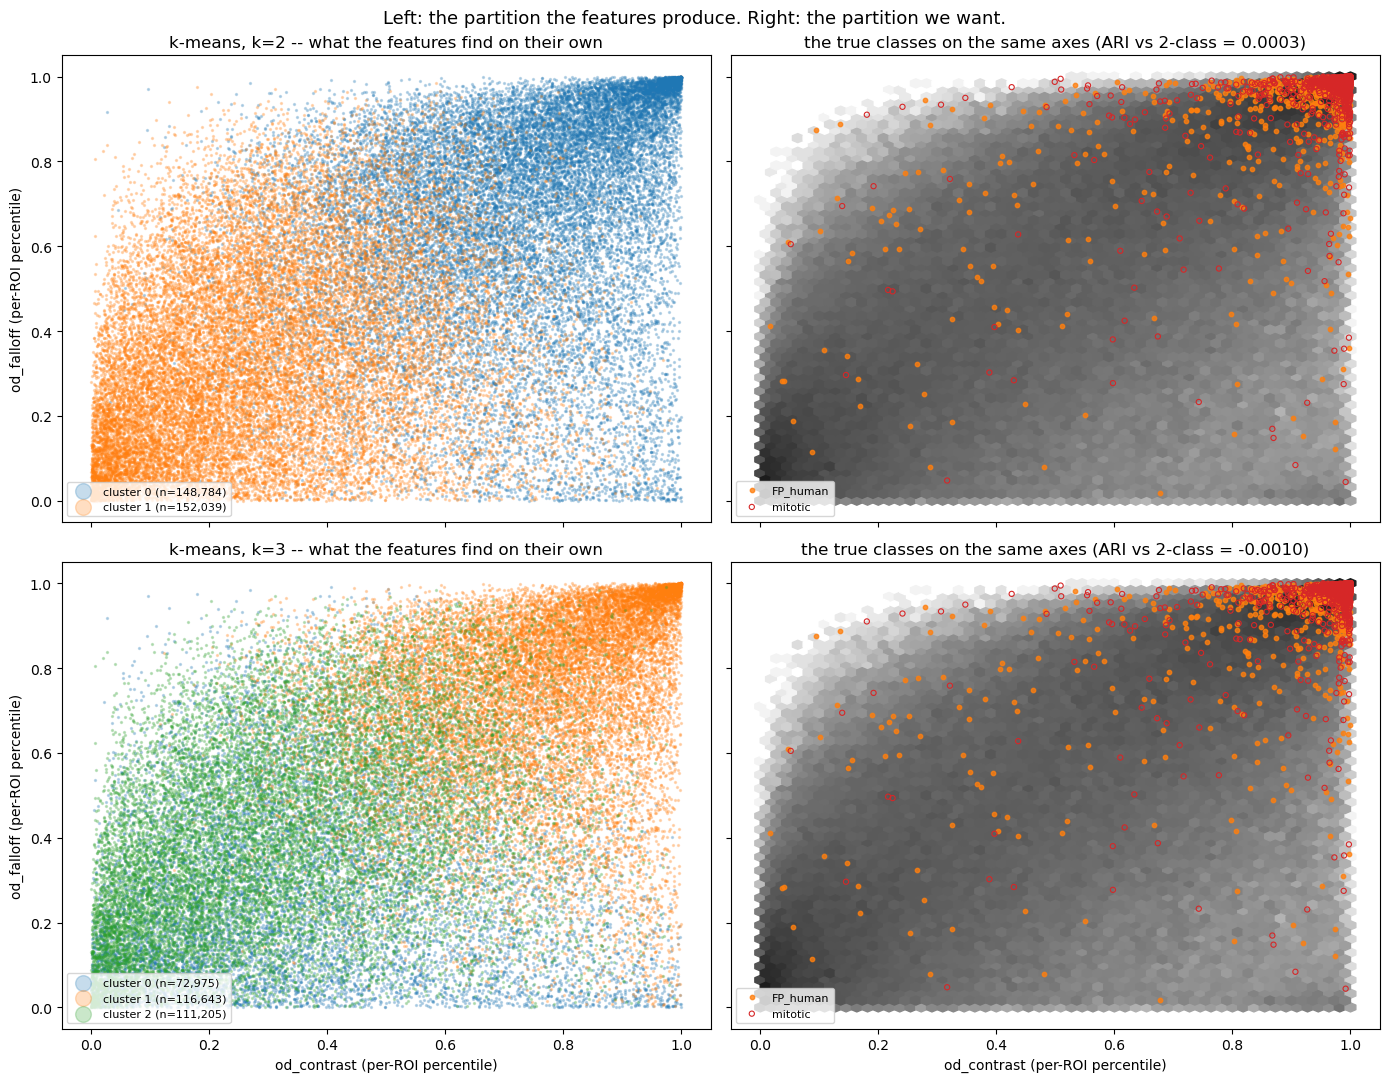

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11), sharex=True, sharey=True)
sub = np.random.default_rng(1).choice(len(work), size=45000, replace=False)
for row, k in enumerate((2, 3)):
    lab = fits[(k, 'k-means')]
    ax = axes[row, 0]
    for c in range(k):
        m = (lab[sub] == c)
        ax.scatter(xa[sub][m], xb[sub][m], s=2, alpha=0.25, label=f'cluster {c} (n={int((lab==c).sum()):,})')
    ax.legend(markerscale=8, fontsize=8, loc='lower left')
    ax.set_title(f'k-means, k={k} -- what the features find on their own')
    ax = axes[row, 1]
    ax.hexbin(xa[~mit & ~(work.klass3 == "FP_human").to_numpy()],
              xb[~mit & ~(work.klass3 == "FP_human").to_numpy()],
              gridsize=55, cmap='Greys', norm=LogNorm(), mincnt=1)
    ax.scatter(xa[(work.klass3 == 'FP_human').to_numpy()],
               xb[(work.klass3 == 'FP_human').to_numpy()], s=10, color='tab:orange',
               alpha=0.8, label='FP_human')
    ax.scatter(xa[mit], xb[mit], s=14, facecolor='none', edgecolor='tab:red', lw=0.8,
               label='mitotic')
    ax.legend(fontsize=8, loc='lower left')
    ax.set_title(f'the true classes on the same axes (ARI vs 2-class = '
                 f'{adjusted_rand_score(y2, lab):.4f})')
for ax in axes[1]:
    ax.set_xlabel(f'{fa} (per-ROI percentile)')
for ax in axes[:, 0]:
    ax.set_ylabel(f'{fb} (per-ROI percentile)')
fig.suptitle('Left: the partition the features produce. Right: the partition we want.', fontsize=13)
fig.tight_layout(); plt.show()

In [22]:
# per ROI, so a pooled null cannot hide an ROI where it does work -- and with the
# [F5] matched-volume threshold beside it in every row.
rows = []
for fn, s in work.groupby('file_name', sort=False):
    Xr = s[FEATURES].rank(pct=True).to_numpy(float)
    yv = (s.klass2 == 'mitotic').to_numpy().astype(int)
    r = {'file': fn, 'domain': s.tumor_type.iloc[0][:22], 'mitotic': int(yv.sum()),
         'base rate': f'{yv.mean():.2%}'}
    for k in (2, 3):
        lab = KMeans(n_clusters=k, n_init=10, random_state=0).fit_predict(Xr)
        obs, which = enrich_of_best(lab, yv)
        nul = perm_null(lab, yv, np.zeros(len(yv)), n_perm=300, seed=k)
        kf = float((lab == which).mean())
        r[f'k={k} enrich'] = round(obs, 2)
        r[f'k={k} null p95'] = round(float(np.percentile(nul, 95)), 2)
        r[f'k={k} beats null'] = obs > np.percentile(nul, 95)
        r[f'k={k} vol'] = f'{kf:.0%}'
        r[f'k={k} recall'] = f'{yv[lab == which].sum() / yv.sum():.1%}'
        v = s.od_falloff.rank(pct=True).to_numpy()
        r[f'k={k} od_falloff @vol'] = f'{yv[v >= np.quantile(v, 1 - kf)].sum() / yv.sum():.1%}'
    rows.append(r)
per_roi_clus = pd.DataFrame(rows)
print('per-ROI clustering (each ROI ranked and clustered on its own)\n')
print(per_roi_clus.to_string(index=False))
beat = (per_roi_clus['k=2 od_falloff @vol'].str.rstrip('%').astype(float)
        >= per_roi_clus['k=2 recall'].str.rstrip('%').astype(float))
print(f'\n[F5] the one-line od_falloff threshold matches or beats k=2 clustering at the same '
      f'volume in {int(beat.sum())} of {len(beat)} ROIs')


per-ROI clustering (each ROI ranked and clustered on its own)

    file                 domain  mitotic base rate  k=2 enrich  k=2 null p95  k=2 beats null k=2 vol k=2 recall k=2 od_falloff @vol  k=3 enrich  k=3 null p95  k=3 beats null k=3 vol k=3 recall k=3 od_falloff @vol
300.tiff canine cutaneous mast       180     0.98%        1.91          1.14            True     52%      99.4%              100.0%        2.21          1.25            True     45%      98.3%               99.4%
301.tiff canine cutaneous mast       217     0.98%        2.00          1.13            True     49%      97.7%               98.6%        3.01          1.19            True     32%      96.3%               97.7%
201.tiff     canine lung cancer       17     0.10%        1.88          1.51            True     53%     100.0%              100.0%        2.92          1.72            True     34%     100.0%              100.0%
233.tiff     canine lung cancer       17     0.07%        1.94          1.46         

## 9. The direct answer: knowing the labels, how far do these features get?

Clustering is label-free and therefore a lower bound. **Using** the labels is the question actually
asked, and the only non-circular way to answer it is to fit on some domains and score another.

**Leave-one-DOMAIN-out, and with 14 ROIs that phrase now has teeth.** `images/extra_valid` holds
two ROIs per tumour type, so holding out a *file* would train on the other ROI of the same domain
— exactly the sibling leak the 7-ROI version criticised in `results/fp_filter_domain.csv`. The
folds below are built on `tumor_type` and each fold is checked against the extraction summary's own
file-to-domain map: 7 folds, both ROIs of a domain held out together, no file in both sides.

The model is fitted on the analysis set (mitosis-duplicates removed) but **scores the full
candidate pool**, because §9's reading depth is what a reader actually works through.


In [23]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score

# One rank basis for everything from here on: the FULL per-ROI candidate pool. That is what is
# available at deployment (you rank the list you just computed, with no outside calibration),
# and it lets the same fitted model score `op` for section 9 without a second basis.
rk_op = op.groupby('file_name')[FEATURES].rank(pct=True)
X_op = rk_op.to_numpy(float)
y_op = (op.bucket == TPB).to_numpy().astype(int)
dom_op = op.tumor_type.to_numpy()
keep = (~op.on_mitosis).to_numpy()          # `work`, expressed as rows of `op`

DOMAINS = list(pd.unique(op.tumor_type))
FILES_OF = summ.groupby('tumor_type').file_name.apply(set).to_dict()   # independent of `op`
op_score = np.full(len(op), np.nan)         # held-out GB score for EVERY candidate
lr_score = np.full(len(op), np.nan)
for d in DOMAINS:
    te = (dom_op == d)
    tr = (~te) & keep
    # leave-one-DOMAIN-out: BOTH ROIs of the domain go out together. With 2 ROIs per domain,
    # holding out a file would train on its sibling -- the exact leak the 7-ROI version
    # criticised in results/fp_filter_domain.csv. Asserted, not assumed.
    # Checked against `summ` rather than against `te` -- an assertion written in terms of
    # `te` alone is tautological, since `tr` is defined as its complement. This one fires if
    # the cache's tumor_type disagrees with the extraction summary, or if a domain's second
    # ROI were ever to go missing from the fold.
    te_files, tr_files = set(op.file_name[te]), set(op.file_name[tr])
    assert te_files == FILES_OF.get(d, set()), (
        f'{d}: held out {sorted(te_files)}, summary says {sorted(FILES_OF.get(d, set()))}')
    assert not (te_files & tr_files), f'{d}: {te_files & tr_files} in both train and test'
    lr = make_pipeline(StandardScaler(),
                       LogisticRegression(max_iter=3000, class_weight='balanced')).fit(X_op[tr], y_op[tr])
    gb = HistGradientBoostingClassifier(max_iter=250, learning_rate=0.08, max_leaf_nodes=15,
                                        l2_regularization=1.0, class_weight='balanced',
                                        random_state=0).fit(X_op[tr], y_op[tr])
    op_score[te] = gb.predict_proba(X_op[te])[:, 1]
    lr_score[te] = lr.predict_proba(X_op[te])[:, 1]
assert not np.isnan(op_score).any(), 'a candidate was never scored by a held-out model'

rows, held = [], {}
for fn, s in op[keep].groupby('file_name', sort=False):
    ix = s.index.to_numpy()
    yv, sc = y_op[ix], op_score[ix]
    held[fn] = (sc, yv)
    br = yv.mean()
    rows.append({'file': fn, 'domain': s.tumor_type.iloc[0][:22], 'mitotic': int(yv.sum()),
                 'base rate': f'{br:.3%}',
                 'LR AUC': round(roc_auc_score(yv, lr_score[ix]), 3),
                 'GB AUC': round(roc_auc_score(yv, sc), 3),
                 'GB AP lift': f'{average_precision_score(yv, sc) / br:.0f}x',
                 'od51 alone AUC': round(roc_auc_score(yv, s.od51), 3),
                 'od_falloff alone AUC': round(roc_auc_score(yv, s.od_falloff), 3),
                 'z alone AUC': round(roc_auc_score(yv, s.z), 3)})
lodo = pd.DataFrame(rows)
print(f'leave-one-DOMAIN-out: {len(DOMAINS)} folds, both ROIs of a domain held out together\n')
print(lodo.to_string(index=False))
print(f'\nGB AUC {lodo["GB AUC"].min():.3f} to {lodo["GB AUC"].max():.3f} on domains the model '
      'never trained on.')


leave-one-DOMAIN-out: 7 folds, both ROIs of a domain held out together

    file                 domain  mitotic base rate  LR AUC  GB AUC GB AP lift  od51 alone AUC  od_falloff alone AUC  z alone AUC
300.tiff canine cutaneous mast       180    0.978%   0.979   0.976        68x           0.955                 0.976        0.930
301.tiff canine cutaneous mast       217    0.981%   0.975   0.974        61x           0.932                 0.971        0.930
201.tiff     canine lung cancer       17    0.103%   0.993   0.993       253x           0.995                 0.976        0.994
233.tiff     canine lung cancer       17    0.067%   0.995   0.998       717x           0.981                 0.995        0.993
245.tiff   canine lymphosarcoma       89    0.247%   0.915   0.912        39x           0.869                 0.854        0.876
246.tiff   canine lymphosarcoma      115    0.433%   0.988   0.993       116x           0.972                 0.991        0.983
459.tiff canine soft tiss

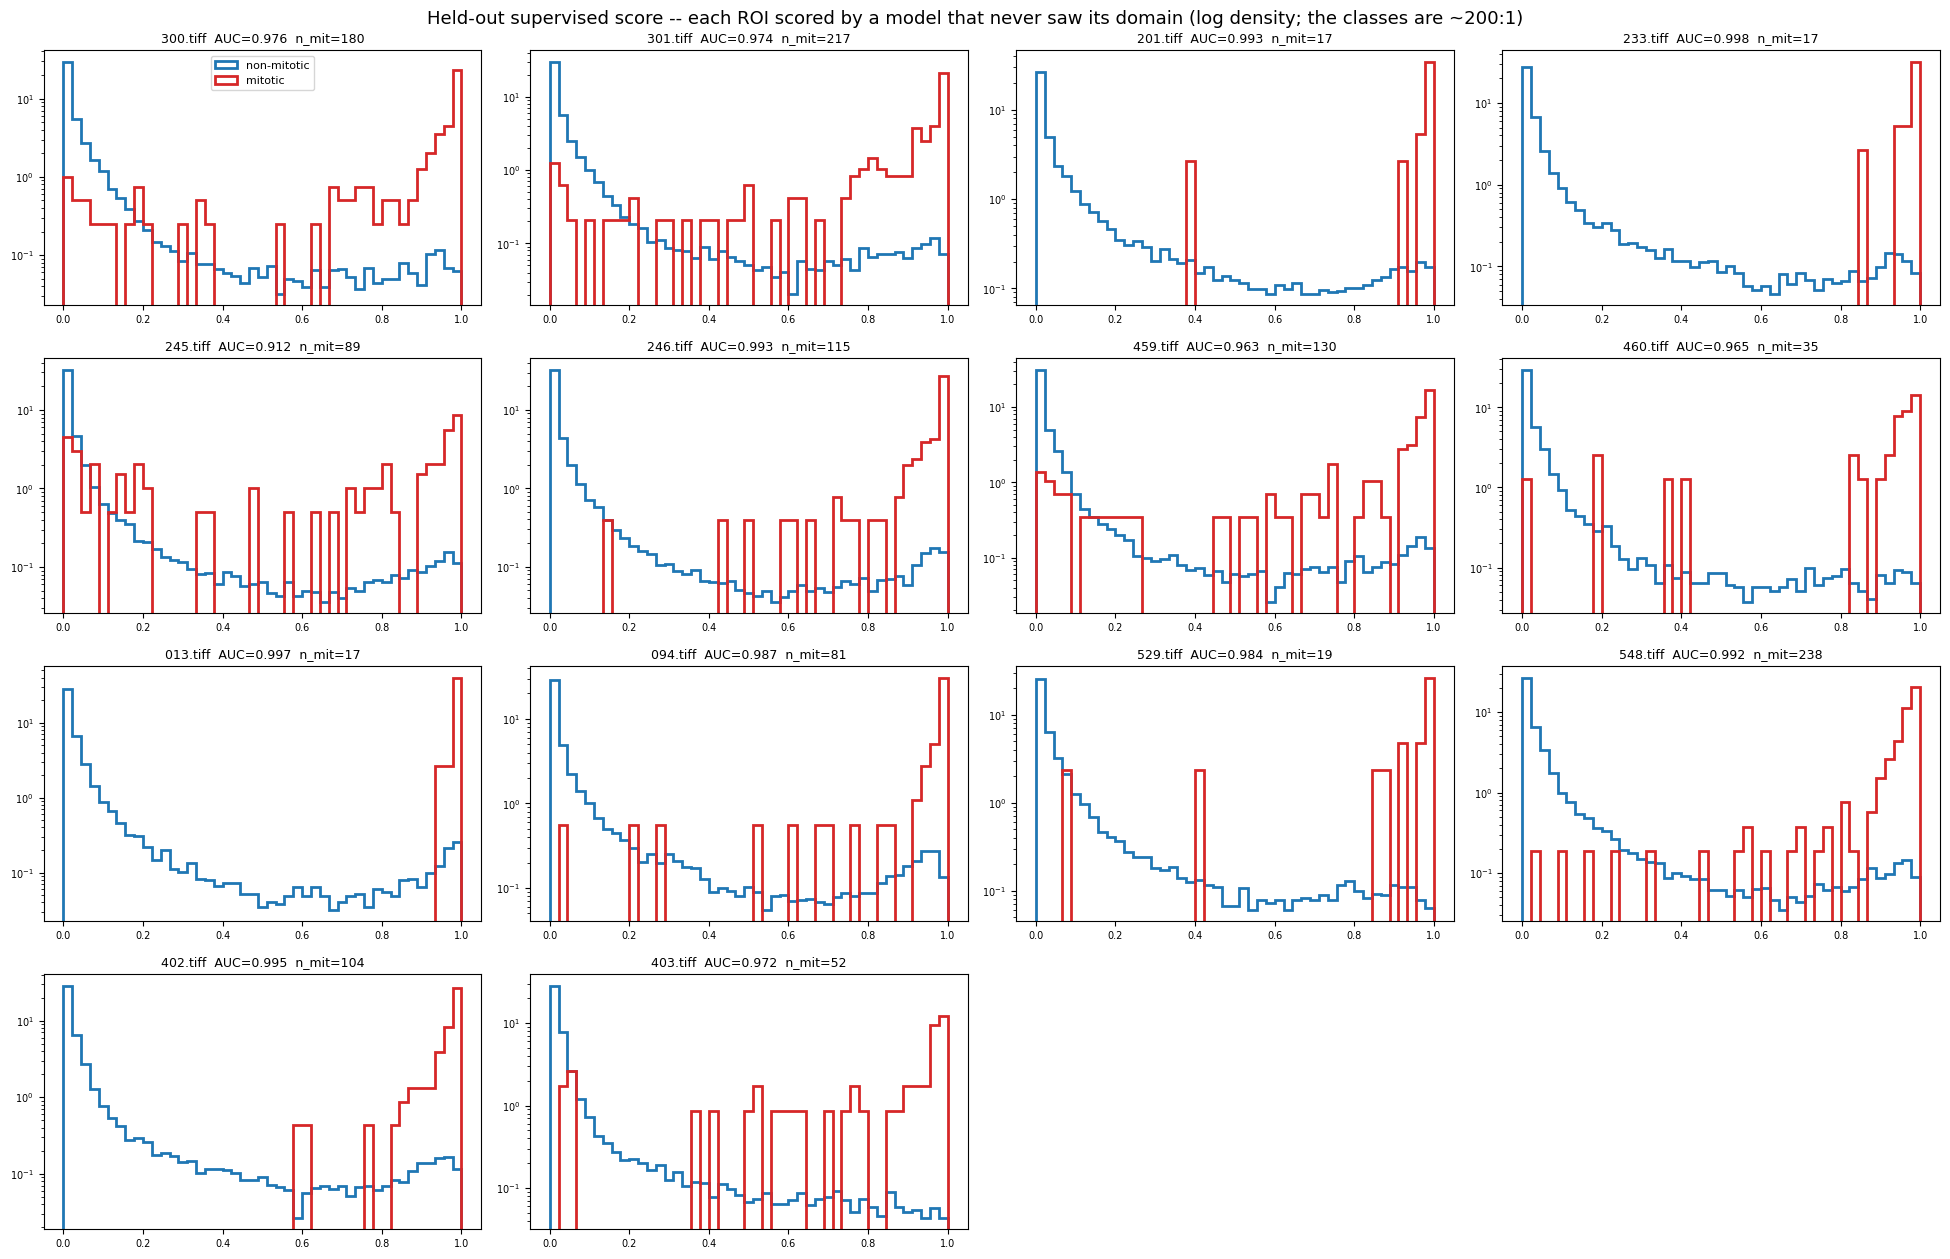

In [24]:
fig, axes = panel_grid(len(held), h=3.2)
for ax, (fn, (s_, y_)) in zip(axes, held.items()):
    bins = np.linspace(0, 1, 46)
    ax.hist(s_[y_ == 0], bins=bins, density=True, histtype='step', lw=2, color='tab:blue',
            label='non-mitotic')
    ax.hist(s_[y_ == 1], bins=bins, density=True, histtype='step', lw=2, color='tab:red',
            label='mitotic')
    ax.set_yscale('log')
    ax.set_title(f'{fn}  AUC={roc_auc_score(y_, s_):.3f}  n_mit={int(y_.sum())}', fontsize=9)
    ax.tick_params(labelsize=7)
axes[0].legend(fontsize=8)
fig.suptitle('Held-out supervised score -- each ROI scored by a model that never saw its domain '
             '(log density; the classes are ~200:1)', fontsize=13)
fig.tight_layout(); plt.show()


In [25]:
# ============================================================================================
# [F2] THE FIX THAT MATTERS MOST HERE. `evaluate.greedy_match` is order-dependent by construction
# (see its docstring: one greedy pass keeps the FROC monotone). The 7-ROI version re-ranked by
# od51 / the supervised score and then counted hits with the bucket labels the match produced
# walking the list in TM-SCORE order. A candidate the new ranker promotes above the TM-order
# winner was scored as a false positive while its mitosis was counted found further down -- so
# every re-ranker was penalised. Here the match is re-run in each ranker's own order.
#
# [F3] every candidate axis goes through the same table, including od_falloff, which the 7-ROI
#      version named its strongest feature and then never measured this way.
# [F4] the comparison is against `z`, the ranker DECISIONS.md D5 ships -- not against od51,
#      which D5 removed from the arbiter.
#
# Depth is measured on the FULL pool `op`, duplicates included: a reader at deployment sees them.
# ============================================================================================
GT_EVAL = {fn: (lambda g: g[g.ann_id != int(seed_of[fn])].reset_index(drop=True))(
               ds.image_annotations(anns, fn)) for fn in op.file_name.unique()}


def cum_hits(sub, score, gt, radius):
    """Cumulative DISTINCT mitoses claimed, with the greedy match re-run in THIS order."""
    o = np.argsort(-np.asarray(score, float), kind='mergesort')
    det_to_gt, _ = ev.greedy_match(sub.iloc[o][['cx', 'cy']].to_numpy(),
                                   gt[['cx', 'cy']].to_numpy(), radius)
    cls = gt.category_id.to_numpy()
    return np.cumsum([(i >= 0 and cls[i] == ds.MITOTIC) for i in det_to_gt])


def read_at(cum, n_mit, q):
    ix = np.searchsorted(cum, int(np.ceil(q * n_mit)), side='left')
    return int(ix) + 1 if ix < len(cum) else np.nan


curves, n_mit_of, rows = {}, {}, []
for fn, s in op.groupby('file_name', sort=False):
    gt = GT_EVAL[fn]
    radius = float(summ.set_index('file_name').match_radius_px[fn])
    n_mit = int((gt.category_id == ds.MITOTIC).sum())
    n_mit_of[fn] = n_mit
    R_ = s[FEATURES].rank(pct=True)
    axes_ = [('z (shipped, D5)', s.z.to_numpy()),
             ('od51', s.od51.to_numpy()),
             ('od_contrast', s.od_contrast.to_numpy()),
             ('od_falloff', s.od_falloff.to_numpy()),
             ('z+od_falloff', (R_.z + R_.od_falloff).to_numpy() / 2),
             ('supervised LODO', op_score[s.index.to_numpy()])]
    for name, sc in axes_:
        cum = cum_hits(s, sc, gt, radius)
        curves[(name, fn)] = cum
        rows.append({'file': fn, 'domain': s.tumor_type.iloc[0][:20], 'n_cand': len(s),
                     'mitotic': n_mit, 'ranker': name,
                     'read_50': read_at(cum, n_mit, .50), 'read_90': read_at(cum, n_mit, .90),
                     'read_95': read_at(cum, n_mit, .95), 'read_100': read_at(cum, n_mit, 1.0)})
tails = pd.DataFrame(rows)
RANKERS = list(dict.fromkeys(tails.ranker))
print('candidates a reader must work through to reach each sensitivity level '
      '(match re-run per ranker)\n')
print(tails.set_index(['file', 'ranker']).drop(columns='domain').to_string())
print('\nread_95 across the 14 ROIs:')
print(tails.groupby('ranker').read_95.agg(['min', 'median', 'max'])
      .reindex(RANKERS).to_string())


candidates a reader must work through to reach each sensitivity level (match re-run per ranker)

                          n_cand  mitotic  read_50  read_90  read_95  read_100
file     ranker                                                               
300.tiff z (shipped, D5)   18451      180      305     3868     6370     11702
         od51              18451      180      142     2435     3314     15076
         od_contrast       18451      180      146     2333     4359     14011
         od_falloff        18451      180      145     1229     1788      7809
         z+od_falloff      18451      180      140     1857     4005     10450
         supervised LODO   18451      180      114      728     2297     11061
301.tiff z (shipped, D5)   22227      217      345     4697     9433     15929
         od51              22227      217      198     4637     7345     17213
         od_contrast       22227      217      166     3113     7231     17981
         od_falloff        22227  

## 10. The operating rule: 95 % recall per ROI on average, with a 90 % floor on every ROI

`read_95` above is a per-ROI quantity. The brief is a rule over ROIs, and the two halves of it can
disagree: a budget chosen so the *mean* clears 95 % can leave the hardest ROI far below 90 %, and a
budget that holds the hardest ROI at 90 % inflates every other list. Both are computed below for
every ranker, at one common budget `K` applied to every ROI, and the point at which they cross is
reported rather than chosen.


In [26]:
# ---- the operating rule: 95% recall per ROI on average, with a 90% floor on every ROI --------
FLOOR, MEAN_TARGET = 0.90, 0.95
# the largest pool, not the smallest: `recall_vec` clips K per ROI, so a K above a short
# ROI's pool is well defined (that ROI contributes its full-pool recall). Bounding KGRID by
# the minimum would make `first_K` return None for a ranker that simply needs a longer list.
KMAX = int(max(len(s) for _, s in op.groupby('file_name')))
KGRID = np.unique(np.concatenate([np.arange(10, 1001, 10),
                                  np.round(np.logspace(3, np.log10(KMAX), 200)).astype(int)]))


def recall_vec(ranker, K):
    return np.array([curves[(ranker, fn)][min(K, len(curves[(ranker, fn)])) - 1] / n_mit_of[fn]
                     for fn in n_mit_of])


def first_K(ranker, fn_agg, target):
    for K in KGRID:
        if fn_agg(recall_vec(ranker, int(K))) >= target:
            return int(K)
    return None


rows = []
for rk_name in RANKERS:
    k_mean = first_K(rk_name, np.mean, MEAN_TARGET)
    k_floor = first_K(rk_name, np.min, FLOOR)
    k_both = None if (k_mean is None or k_floor is None) else max(k_mean, k_floor)
    r = {'ranker': rk_name,
         'read_95 median': round(float(tails[tails.ranker == rk_name].read_95.median()), 1),
         'read_95 max': int(tails[tails.ranker == rk_name].read_95.max()),
         'K for mean recall >= 95%': k_mean,
         'K for EVERY ROI >= 90%': k_floor,
         'K meeting both': k_both}
    if k_both is not None:
        v = recall_vec(rk_name, k_both)
        r['mean recall @K'] = f'{v.mean():.1%}'
        r['worst ROI @K'] = f'{v.min():.1%}'
        r['ROIs below 95% @K'] = int((v < 0.95).sum())
    rows.append(r)
budget = pd.DataFrame(rows)
print(f'operating rule: mean recall >= {MEAN_TARGET:.0%} across ROIs, floor of {FLOOR:.0%} on '
      f'every individual ROI\n(one common budget K applied to every ROI; KMAX = {KMAX:,})\n')
print(budget.to_string(index=False))

feasible = budget.dropna(subset=['K meeting both'])
if len(feasible) == 0:
    raise AssertionError(f'no ranker meets {MEAN_TARGET:.0%} mean AND a {FLOOR:.0%} floor at any '
                         f'K <= {KMAX:,}. That is itself the result -- report it, do not widen K.')
if len(feasible) < len(budget):
    print(f'\n{len(budget) - len(feasible)} ranker(s) fail at least one bound at any '
          f'K <= {KMAX:,}: {sorted(set(budget.ranker) - set(feasible.ranker))}')
best = feasible.sort_values('K meeting both').iloc[0]
BEST_RANKER, K_STAR = best.ranker, int(best['K meeting both'])
print(f'\ncheapest ranker satisfying both: {BEST_RANKER} at K = {K_STAR:,}')
v = recall_vec(BEST_RANKER, K_STAR)
per_roi = pd.DataFrame({'file': list(n_mit_of), 'domain': [DOMAIN_OF[f][:24] for f in n_mit_of],
                        'mitotic': [n_mit_of[f] for f in n_mit_of],
                        'recall @K': [f'{x:.1%}' for x in v],
                        'meets 90% floor': v >= FLOOR}).sort_values('recall @K')
print(f'\nper-ROI at K = {K_STAR:,}:')
print(per_roi.to_string(index=False))
print('\nNOTE  K here is chosen with the held-out labels in hand -- it is an ORACLE budget, and\n'
      '      states what the ranker could deliver, not a deployable rule. Choosing K from\n'
      '      ROI-observable quantities is the next piece of work; see section 11.')

# ---- artefacts ------------------------------------------------------------------------------
answer = {
    'ROIs / domains': f'{op.file_name.nunique()} ROIs, {op.tumor_type.nunique()} domains, '
                      '2 per domain (images/extra_valid)',
    'negative class': f'the TM_CCOEFF + NMS candidate pool at z >= {Z_OP}, not a uniform nucleus sample',
    'candidates / mitotic (analysis set)': f'{len(work):,} / {int(y2.sum())}',
    'base rate per ROI': f'{work.groupby("file_name").klass2.apply(lambda s: (s == "mitotic").mean()).min():.2%}'
                         f' to {work.groupby("file_name").klass2.apply(lambda s: (s == "mitotic").mean()).max():.2%}',
    '[F1] set aside: FPs on a MITOSIS': f'{int(op.on_mitosis.sum())} '
                                        f'({op.on_mitosis.sum() / y2.sum():.2f} per mitotic figure)',
    '[F1] kept in negatives: FPs on a LOOK-ALIKE': f'{int(op.on_lookalike.sum())} '
                                                   f'({100 * op.on_lookalike.sum() / op.on_annotation.sum():.0f}% '
                                                   'of what the old rule removed)',
    '[F6] coverage_frac at the operating point': f'{cov.coverage_frac.min():.3f} to {cov.coverage_frac.max():.3f}',
    'od_falloff AUC vs FP': f'{aucFP.od_falloff.min():.3f} to {aucFP.od_falloff.max():.3f}',
    'od_falloff AUC vs FP_human': f'{aucH.od_falloff.min():.3f} to {aucH.od_falloff.max():.3f}',
    'od51 AUC vs all non-mitotic': f'{auc2.od51.min():.3f} to {auc2.od51.max():.3f}',
    'supervised LODO AUC': f'{lodo["GB AUC"].min():.3f} to {lodo["GB AUC"].max():.3f}',
    'k=2 enrichment / null p95 / ARI':
        f'{clus[(clus.k == 2) & (clus.method == "k-means")].enrichment.iloc[0]:.2f}x / '
        f'{clus[(clus.k == 2) & (clus.method == "k-means")]["null p95"].iloc[0]:.2f}x / '
        f'{clus[(clus.k == 2) & (clus.method == "k-means")]["ARI"].iloc[0]:.4f}',
    '[F5] k=2 recall vs od_falloff at same volume':
        f'{clus[(clus.k == 2) & (clus.method == "k-means")]["recall"].iloc[0]} vs '
        f'{clus[(clus.k == 2) & (clus.method == "k-means")]["od_falloff @same vol"].iloc[0]}',
    '[F3] read_95 median, best cheap axis':
        f'{tails.groupby("ranker").read_95.median().drop("supervised LODO").idxmin()} at '
        f'{tails.groupby("ranker").read_95.median().drop("supervised LODO").min():,.1f}',
    '[F4] read_95 median, supervised vs z (shipped)':
        f'{tails[tails.ranker == "supervised LODO"].read_95.median():,.1f} vs '
        f'{tails[tails.ranker == "z (shipped, D5)"].read_95.median():,.1f}',
    'cheapest K meeting 95% mean + 90% floor': f'{BEST_RANKER} at K = {K_STAR:,} (oracle)',
}
out = pd.DataFrame(answer.items(), columns=['quantity', 'value'])
pd.set_option('display.max_colwidth', 110)
print('\n')
print(out.to_string(index=False))

out.to_csv('results/tp_fp_separability_14roi_summary.csv', index=False)
auc2.to_csv('results/tp_fp_14roi_auc_2class.csv', index=False)
aucFP.to_csv('results/tp_fp_14roi_auc_vs_fp.csv', index=False)
aucH.to_csv('results/tp_fp_14roi_auc_vs_fp_human.csv', index=False)
clus.to_csv('results/tp_fp_14roi_cluster_k2_k3.csv', index=False)
per_roi_clus.to_csv('results/tp_fp_14roi_cluster_per_roi.csv', index=False)
lodo.to_csv('results/tp_fp_14roi_lodo_supervised.csv', index=False)
tails.to_csv('results/tp_fp_14roi_reading_depth.csv', index=False)
budget.to_csv('results/tp_fp_14roi_budget_rule.csv', index=False)
cov.to_csv('results/tp_fp_14roi_coverage.csv', index=False)
delta.to_csv('results/tp_fp_14roi_setaside_sensitivity.csv', index=False)
print('\nwrote 11 tables to results/')


operating rule: mean recall >= 95% across ROIs, floor of 90% on every individual ROI
(one common budget K applied to every ROI; KMAX = 36,284)

         ranker  read_95 median  read_95 max  K for mean recall >= 95%  K for EVERY ROI >= 90%  K meeting both mean recall @K worst ROI @K  ROIs below 95% @K
z (shipped, D5)          1993.5        14988                      5357                   12739           12739          99.1%        91.0%                  1
           od51          3709.5        17946                      4637                    9895            9895          98.2%        91.0%                  2
    od_contrast          3074.0         9778                      3232                    5655            5655          97.1%        91.0%                  4
     od_falloff          1954.5         9487                      2603                    7280            7280          98.4%        90.4%                  2
   z+od_falloff          1781.0         9580                      



                                      quantity                                                                        value
                                ROIs / domains                        14 ROIs, 7 domains, 2 per domain (images/extra_valid)
                                negative class the TM_CCOEFF + NMS candidate pool at z >= 1.0, not a uniform nucleus sample
           candidates / mitotic (analysis set)                                                               300,823 / 1311
                             base rate per ROI                                                               0.07% to 1.15%
              [F1] set aside: FPs on a MITOSIS                                                913 (0.70 per mitotic figure)
   [F1] kept in negatives: FPs on a LOOK-ALIKE                                       900 (50% of what the old rule removed)
     [F6] coverage_frac at the operating point                                                               0.743 to 0.998
      

## 11. The answer

**The features separate mitotic figures from the search's own false positives, on 14 ROIs across
7 domains. Almost none of that separation shortens the list to anything a reader would call
short — and the ranking that wins on the median is not the ranking that wins under a floor.**

### What replicated from the 7-ROI version

**1. On the bulk, separation is close to complete.** Every chromatin feature reads AUC 0.855–0.998
against the unannotated false positives in all 14 ROIs, with average-precision lifts of 9x to 811x
over base rates of 0.067–1.15 %. **But the floor moved.** The 7-ROI version reported a minimum of
0.92; adding the second ROI per domain brings in `245.tiff` (canine lymphosarcoma) at 0.855–0.906
and an AP lift of only 9–17x (0.854–0.905 on the 2-class table). A range quoted from 7 ROIs was
optimistic by ~0.07 AUC.

**2. Against the look-alikes, separation collapses — confirmed.** 0.44–0.89, and `od_falloff` sits
*below chance* on `459.tiff` at 0.441. They are 973 of 300,823 candidates, so they are not the
volume problem; they remain the part no feature here touches.

**3. Shape is real and weak — confirmed.** `solidity` 0.60–0.93 and `extent` 0.53–0.86, against AP
lifts of 1–9x versus chromatin's 9–811x. `tightened_size` says mitoses measure *smaller* in all 14
ROIs. They separate; they do not rank.

**4. No ranker reaches the tail cheaply — confirmed.** `read_100` for `z` runs 665 to 16,226, and no axis is uniformly better: the supervised model's worst `read_100` is 31,432, the largest of the six.

### What did not replicate

**5. `od_falloff`'s advantage over the shipped ranker is gone.** On 7 ROIs it cut `z`'s median
`read_95` by 22 % (1,492 vs 1,912). On 14 it is a dead heat: **1,954.5 vs 1,993.5** — a 2 % difference
against a click-to-click SD of 260–2,744 candidates
(`results/tm_ccoeff_headtohead_seed_variance.csv`). It is not a difference. Its *worst* ROI is
still much better (9,487 vs 14,988) — but both of those are `245.tiff`, the same single ROI that
turns out to decide everything in §10, so read that as one measurement rather than a property.

**What did replicate is the [F4] baseline error.** `od51` is the *worst* of the six axes at median
`read_95` (3,709.5). The 7-ROI version quoted its supervised gain as "3–8x" against exactly that
axis — the one `DECISIONS.md` D5 had already removed from the arbiter.

**6. [F5] Clustering does not beat `sort()`, but the margin is thinner than 7 ROIs suggested.**
k = 2 puts 98.8 % of mitoses in 49.5 % of the pool. A per-ROI percentile threshold on `od_falloff`
at the *same volume* gets 98.3 % pooled — so pooled, k-means is ahead by half a point, where on
7 ROIs the threshold won outright. Per ROI the threshold still matches or beats it in **13 of 14**.
The honest reading is that the two are within a few tenths of a point of each other, which is
still a reason not to ship a fitted, non-monotone, initialisation-dependent object. And the ARI of
0.0003 says what it said before: no partition isolates the mitoses.

**7. [F6] The coverage number is worse than the 7-ROI set implied and cuts the other way.**
`coverage_frac` spans **0.743–0.998**, against 0.896–0.992 on the original seven. `full_list_recall
= 1.0` at this density is substantially geometric. It does not weaken the separability result — the
positive class is complete either way — but the sentence the 7-ROI version wrote was unsupported.

### The rule, and the finding that only appears under it

**8. Under 95 % mean recall with a 90 % floor on every ROI, the ordering changes — and one ROI
decides all of it.**

| ranker | median `read_95` | K for mean ≥ 95 % | K for **every** ROI ≥ 90 % | K meeting both |
|---|---|---|---|---|
| `od_contrast` | 3,074.0 | 3,232 | **5,655** | **5,655** |
| supervised LODO | **1,283.0** | **1,628** | 6,078 | 6,078 |
| `z+od_falloff` | 1,781.0 | 2,556 | 7,022 | 7,022 |
| `od_falloff` | 1,954.5 | 2,603 | 7,280 | 7,280 |
| `od51` | 3,709.5 | 4,637 | 9,895 | 9,895 |
| `z` (shipped, D5) | 1,993.5 | 5,357 | 12,739 | 12,739 |

Two things are true of that table and **only one of them is a result.**

*What holds.* Every ranker's binding constraint is the **floor**, not the mean — `K for every ROI
≥ 90 %` exceeds `K for mean ≥ 95 %` in all six rows. The promise is therefore priced by the worst
ROI, and the axis with the best median need not win it. Against `z`, the ranker the repo ships,
`od_contrast` costs **5,655 against 12,739** — 2.3x — and on the deciding ROI that is 5,561 against
12,554, a margin of ~7,000 candidates.

*What does not hold, and the notebook should not be read as claiming it.* **All six floors are set
by the same ROI, `245.tiff`.** Its `read_90` is the maximum for every ranker in the table —
`od_contrast` 5,561, supervised 6,018, `z+od_falloff` 6,964, `od_falloff` 7,175, `od51` 9,879, `z`
12,554 — so the last column is a ranking of *one ROI's depth curve, at one click, with 89 mitoses*.
`results/tm_ccoeff_headtohead_seed_variance.csv` measures that ROI's own click-to-click SD of
`read_95` at **2,153 candidates** over 5 seeds (mean 11,190, range 9,762–14,956). The
`od_contrast`-over-supervised margin is 423 candidates — **0.2 SD**. §12's own rule says a
difference smaller than that band is not resolved, and this one is not. The `od_contrast`-over-`z`
margin is ~7,000, over 3 SD, and is.

There is a second reason not to lean on the near-tie: `od_contrast` was selected as best-of-six on
the same 14 ROIs it is scored on, and the selection turns on a single ROI's measurement.

**The claim this notebook supports: `od_contrast` gives a 2.3x shorter list than the shipped ranker
at the stated guarantee, from one within-image difference (`od51 − od_ctx`) that needs no training
and no calibration. The claim it does not support: that it beats the supervised model.** On the
median the supervised model is 2.4x better; under the floor it is 7 % worse; the second of those is
inside the noise. What is worth carrying forward is the structural point — a floor is priced by the
hard ROI, so median depth is the wrong statistic for choosing a ranker under this brief.

**9. And the shortlist is not short.** At K = 5,655 the mean recall is 97.1 %, the worst ROI is
91.0 %, and 4 of 14 ROIs sit below 95 %. K = 5,655 is 16–43 % of each ROI's candidate pool. The
7-ROI version's read of this was right and the 14-ROI numbers are worse: re-ranking moves the
95 %-sensitivity depth by a factor of two or three, and 0.4 % prevalence sets the scale. Nothing
here turns 20,000 candidates into 200.

**10. What actually changed hands.** Against `z`, the cheapest rule costs **5,655 instead of
12,739** — a 2.3x shorter list at the stated guarantee, from a feature that needs only the ROI's own
candidates. That is the deliverable. Two limits travel with it: `K` is an **oracle**, chosen knowing
each ROI's mitosis count; and the ranker is a best-of-six pick decided by one ROI at one click. §12
says what would have to be built to claim either at deployment.


## 12. Limitations

- **One seed per ROI, and that is the binding one.** `results/tm_ccoeff_headtohead_seed_variance.csv`
  puts the click-to-click SD of `read_95` at **260–2,744 candidates** over 5 seeds. Every ranker
  comparison in §9 is at `seed_index = 0`. Differences between the cheap axes that are smaller
  than that band are not resolved here, and should not be read as resolved. The supervised-vs-`z`
  gap is the only one large enough to survive it on the face of it, and even that wants the
  14 ROI × 5 seed grid `recall_workload_ledger.py` already builds.
- **`K` in §10 is an oracle.** It is chosen knowing each ROI's mitosis count and the achieved
  recall. A deployable rule has to pick `K` from ROI-observable quantities — pool size, score
  distribution, the click's own features — fitted on other domains and validated on the held-out
  one. `results/tm_recall_workload_tolerance.csv` and `..._lodo.csv` are that shape on the
  `tm_score` axis; running them on the axes here is the next piece of work, not this notebook.
- **Shape is "the largest dark component in the 51 px window", not "the object under the click."**
  The segmentation is deliberately gate-free — `morphometric_diagnostic_audit.ipynb` §11 showed the
  usual `min_area` / `max_area_frac` / `min_solidity` gates truncate the very features being
  compared, and drop 9–12 % of detections non-randomly. The price is that for a candidate not
  sitting on a nucleus, the measured component may belong to a neighbouring object.
- **`z` is censored by construction.** The pool is *defined* by `z >= 1.0`, so its distribution is
  truncated at the operating point and its AUC understates what the score does over its full range.
  It is excluded from every "best feature" selection for that reason, and kept in the tables — and
  in §9, where the censoring does not apply because depth is measured within the pool.
- **Per-ROI ranking removes between-ROI signal** (§5), and the domain-predictability test for it is
  close to tautological (§5 note). `od_contrast` and `od_falloff` are within-image differences and
  the per-ROI tables need no normalisation, so both are reported.
- **The largest-CC arm is a known-slightly-worse ranker.** `Research Logs/2026-09-04-f1-results.md`
  found tightening hurts ranking dose-dependently below ~36 px. It is the arm the extraction was
  built on, and it is a *ranking* finding rather than a feature-structure one, but anything
  load-bearing should be re-checked on `base51`.
- **Small-`n` ROIs.** `images/extra_valid`'s bar is `n_mitotic >= 15`. On an ROI with 17 mitoses,
  `ceil(0.95 x 17) = 17`, so `read_95` **is** `read_100` by construction and any "shorter on N of
  14" tally partly counts an artefact. Those rows are reported and should not carry weight.
- **Two things changed at once versus the 7-ROI notebook** — the ROI count and the F1 negative
  class. §6's sensitivity table isolates the second so a shift can be attributed.
